In [ ]:
!pip install pgmpy
!pip install daft


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.0 MB/s eta 0:00:00


In [ ]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense
from keras.metrics import AUC
from imblearn.over_sampling import SMOTE

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os
import gc
import pdb

# Import Libraries

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the Excel file into a DataFrame
#file_path = '/content/drive/MyDrive/longcovid.csv'
#longcovid = pd.read_csv(file_path)  # Replace 'Sheet1' with the actual sheet name
#lc2=pd.read_excel(file_path, sheet_name='Follow-up at 6 months')


In [ ]:
loncovid=pd.read_csv("loncov.csv")

In [ ]:
longcovid.shape

(487, 53)

In [ ]:
# List of underlying conditions
underlying_conditions = ['diabetes', 'hypertension', 'asthma',
                         'cancer', 'tb', 'cancer', 'anxiety',
                        'obesity', 'other_medical']
# Creating the 'under_cond' column
longcovid['under_cond'] = longcovid[underlying_conditions].any(axis=1).astype(int)

In [ ]:
# Replacing values of 2 with 1 in the 'longcovid_six' column
longcovid['longcovid_six'] = longcovid['longcovid_six'].replace(2, 1)

In [ ]:
# Replacing values of 2 with 1 in the 'longcovid_six' column
longcovid['vaccine_effect'] = longcovid['vaccine_effect'].replace(3, 2)

In [ ]:
 #Replacing values of 2 with 1 in the 'longcovid_six' column
longcovid['lc_activitylimit_four'] = longcovid['lc_activitylimit_four'].replace(2, 1)

In [ ]:
 #Replacing values of 2 with 1 in the 'longcovid_six' column
longcovid['longcovid_four'] = longcovid['longcovid_four'].replace(2, 1)

In [ ]:
longcovid['Age_group'].value_counts()

2    231
3    136
1     90
4     30
Name: Age_group, dtype: int64

In [ ]:
covidpgm = PGM(shape=[15,15])
# Background

covidpgm.add_node(daft.Node('education','Education',4,4, scale=1.5))
covidpgm.add_node(daft.Node('sex','Gender',3,4, scale=1.5))
covidpgm.add_node(daft.Node('Age_group','Age Group',4.3,13, scale=1.5))
covidpgm.add_node(daft.Node('smoking','Smoking',2,4, scale=1.5))
covidpgm.add_node(daft.Node('alcohol','Alcohol',2,7, scale=1.5))
covidpgm.add_node(daft.Node('drugs','Drugs',2,8, scale=1.5))
covidpgm.add_node(daft.Node('occupation','Occupation',2,5, scale=1.5))
covidpgm.add_node(daft.Node('occupation_covid','Occupation\nCovid',2,6, scale=1.5))
covidpgm.add_node(daft.Node('past_history_covid','History\nCOVID',2,10, scale=1.5))
covidpgm.add_node(daft.Node('date_diff_four_4_classes','days since\nCOVID',2,9, scale=1.5))

# Underlying Condition
covidpgm.add_node(daft.Node('under_cond','Under\nCond',2,12, scale=1.5))
covidpgm.add_node(daft.Node('hypertension','Hyper\ntension',1,12, scale=1.5))
covidpgm.add_node(daft.Node('anxiety','Anxiety',1,13, scale=1.5))
covidpgm.add_node(daft.Node('asthma','Asthma',1,14, scale=1.5))
covidpgm.add_node(daft.Node('cancer','Cancer',2,14, scale=1.5))
covidpgm.add_node(daft.Node('diabetes','Diabetes',3,14, scale=1.5))
covidpgm.add_node(daft.Node('other_medical','Other\nCond',3,13, scale=1.5))
covidpgm.add_node(daft.Node('obesity','Obesity',3,12, scale=1.5))
covidpgm.add_node(daft.Node('tb','TB',2,11, scale=1.5))

# Vaccines
covidpgm.add_node(daft.Node('vaccine_dose','Vaccine\nDose',6,13, scale=1.5))
covidpgm.add_node(daft.Node('vaccine_type','Vaccine\nType',6,12, scale=1.5))
covidpgm.add_node(daft.Node('vaccine_effect','Vaccine\nEffects',7,13, scale=1.5))

'''# LC Symptoms
covidpgm.add_node(daft.Node('lc_fatigue_four','LC Fatig',10.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_cough_four','LC Cough',4.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_headache_four','LC Headache',5,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_breathing_four','LC Diff\nBreathing',5.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_taste_four','LC Loss\nTaste',6,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_smell_four','LC Loss\nSmell',6.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_brainfog_four','LC Fog\nBrain',7,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_chestpain_four','LC Pain\nChest',7.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_palpitation_four','LC Palpit',8,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_anxiety_four','LC Anxie',8.5,11, scale=1.5))
covidpgm.add_node(daft.Node('lc_fever_four','LC Fever',9,10, scale=1.5))
covidpgm.add_node(daft.Node('lc_other_four','LC Other',9.5,11, scale=1.5))'''

# Covid Symptoms
covidpgm.add_node(daft.Node('covid_severity','COVID\nSeverity',8,4, scale=1.5))
covidpgm.add_node(daft.Node('covid_care','COVID\nCare',7,4, scale=1.5))

covidpgm.add_node(daft.Node('Headache','Headache',11,8, scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',11,6, scale=1.5))
covidpgm.add_node(daft.Node('Fever','Fever',11,9, scale=1.5))
covidpgm.add_node(daft.Node('Ageusia','Ageusia',11,5, scale=1.5))
covidpgm.add_node(daft.Node('Anosmia','Anosmia',11,10, scale=1.5))
covidpgm.add_node(daft.Node('SoreThroat','Sore\nThroat',11,4, scale=1.5))
covidpgm.add_node(daft.Node('DigestiveIssues','Digestv\nIssue',11,11, scale=1.5))
covidpgm.add_node(daft.Node('Cold','Cold',10,4, scale=1.5))
covidpgm.add_node(daft.Node('OtherSymptoms','Other\nSymp',11,12, scale=1.5))
covidpgm.add_node(daft.Node('Bodyache','Body\nAche',11,13, scale=1.5))
covidpgm.add_node(daft.Node('BreathingDifficulty','Breathe\nDiff',11,12, scale=1.5))
covidpgm.add_node(daft.Node('NasalIssues','Nasal\nIssues',9,4, scale=1.5))
covidpgm.add_node(daft.Node('Fatigue','Fatig',11,14, scale=1.5))
covidpgm.add_node(daft.Node('ChestPain','Chest\nPain',11,7, scale=1.5))
covidpgm.add_node(daft.Node('Obesity','Obesity',9,14, scale=1.5))

# LONG COVID
covidpgm.add_node(daft.Node('longcovid_four','LC 4\nWeeks',6,11, scale=1.5))
#covidpgm.add_node(daft.Node('longcovid_six','LC 6\nMonths',6,7, scale=1.5))
covidpgm.add_node(daft.Node('lc_activitylimit_four','LC 4\nAct Limit',5,4, scale=1.5))
covidpgm.add_node(daft.Node('lc_consultation_four','LC 4\nConsult',6,4, scale=1.5))

In [ ]:
# Background
covidpgm.add_edge('Age_group','longcovid_four')
covidpgm.add_edge('sex','longcovid_four')
covidpgm.add_edge('education','longcovid_four')
covidpgm.add_edge('smoking','longcovid_four')
covidpgm.add_edge('alcohol','longcovid_four')
covidpgm.add_edge('drugs','longcovid_four')
covidpgm.add_edge('occupation','longcovid_four')
covidpgm.add_edge('occupation_covid','longcovid_four')
covidpgm.add_edge('past_history_covid','longcovid_four')
covidpgm.add_edge('date_diff_four_4_classes','longcovid_four')

# Underlying Condition
covidpgm.add_edge('under_cond','longcovid_four')
covidpgm.add_edge('hypertension','under_cond')
covidpgm.add_edge('anxiety','under_cond')
covidpgm.add_edge('asthma','under_cond')
covidpgm.add_edge('cancer','under_cond')
covidpgm.add_edge('diabetes','under_cond')
covidpgm.add_edge('other_medical','under_cond')
covidpgm.add_edge('obesity','under_cond')
covidpgm.add_edge('tb','under_cond')
covidpgm.add_edge('Obesity','longcovid_four')


# Vaccines
#highest dose, mix or covi or covax, effect
#dose > type > lc
#dose > effect > lc
#type > effect
#dose > lc ??
covidpgm.add_edge('vaccine_dose','vaccine_type')
covidpgm.add_edge('vaccine_type','longcovid_four')
covidpgm.add_edge('vaccine_type','vaccine_effect')
covidpgm.add_edge('vaccine_effect','longcovid_four')
covidpgm.add_edge('Age_group','vaccine_dose')

'''# LC Symptoms
covidpgm.add_edge('lc_fatigue_four','longcovid_six')
covidpgm.add_edge('lc_cough_four','longcovid_six')
covidpgm.add_edge('lc_headache_four','longcovid_six')
covidpgm.add_edge('lc_breathing_four','longcovid_six')
covidpgm.add_edge('lc_taste_four','longcovid_six')
covidpgm.add_edge('lc_smell_four','longcovid_six')
covidpgm.add_edge('lc_brainfog_four','longcovid_six')
covidpgm.add_edge('lc_chestpain_four','longcovid_six')
covidpgm.add_edge('lc_palpitation_four','longcovid_six')
covidpgm.add_edge('lc_anxiety_four','longcovid_six')
covidpgm.add_edge('lc_fever_four','longcovid_six')
covidpgm.add_edge('lc_other_four','longcovid_six')'''

# Covid Symptoms
covidpgm.add_edge('covid_severity','longcovid_four')
covidpgm.add_edge('covid_care','longcovid_four')
covidpgm.add_edge('Headache','longcovid_four')
covidpgm.add_edge('Cough','longcovid_four')
covidpgm.add_edge('Fever','longcovid_four')
covidpgm.add_edge('Ageusia','longcovid_four')
covidpgm.add_edge('Anosmia','longcovid_four')
covidpgm.add_edge('SoreThroat','longcovid_four')
covidpgm.add_edge('DigestiveIssues','longcovid_four')
covidpgm.add_edge('Cold','longcovid_four')
covidpgm.add_edge('OtherSymptoms','longcovid_four')
covidpgm.add_edge('Bodyache','longcovid_four')
covidpgm.add_edge('BreathingDifficulty','longcovid_four')
covidpgm.add_edge('NasalIssues','longcovid_four')
covidpgm.add_edge('ChestPain','longcovid_four')
covidpgm.add_edge('Fatigue','longcovid_four')



# LONG COVID
#4 > 6
#everything > 6
#covid symp > 6 months
#covid symp > 4weeks

covidpgm.add_edge('lc_activitylimit_four','longcovid_four')
#covidpgm.add_edge('lc_activitylimit_four','longcovid_six')
covidpgm.add_edge('lc_consultation_four','longcovid_four')
#covidpgm.add_edge('lc_consultation_four','longcovid_six')

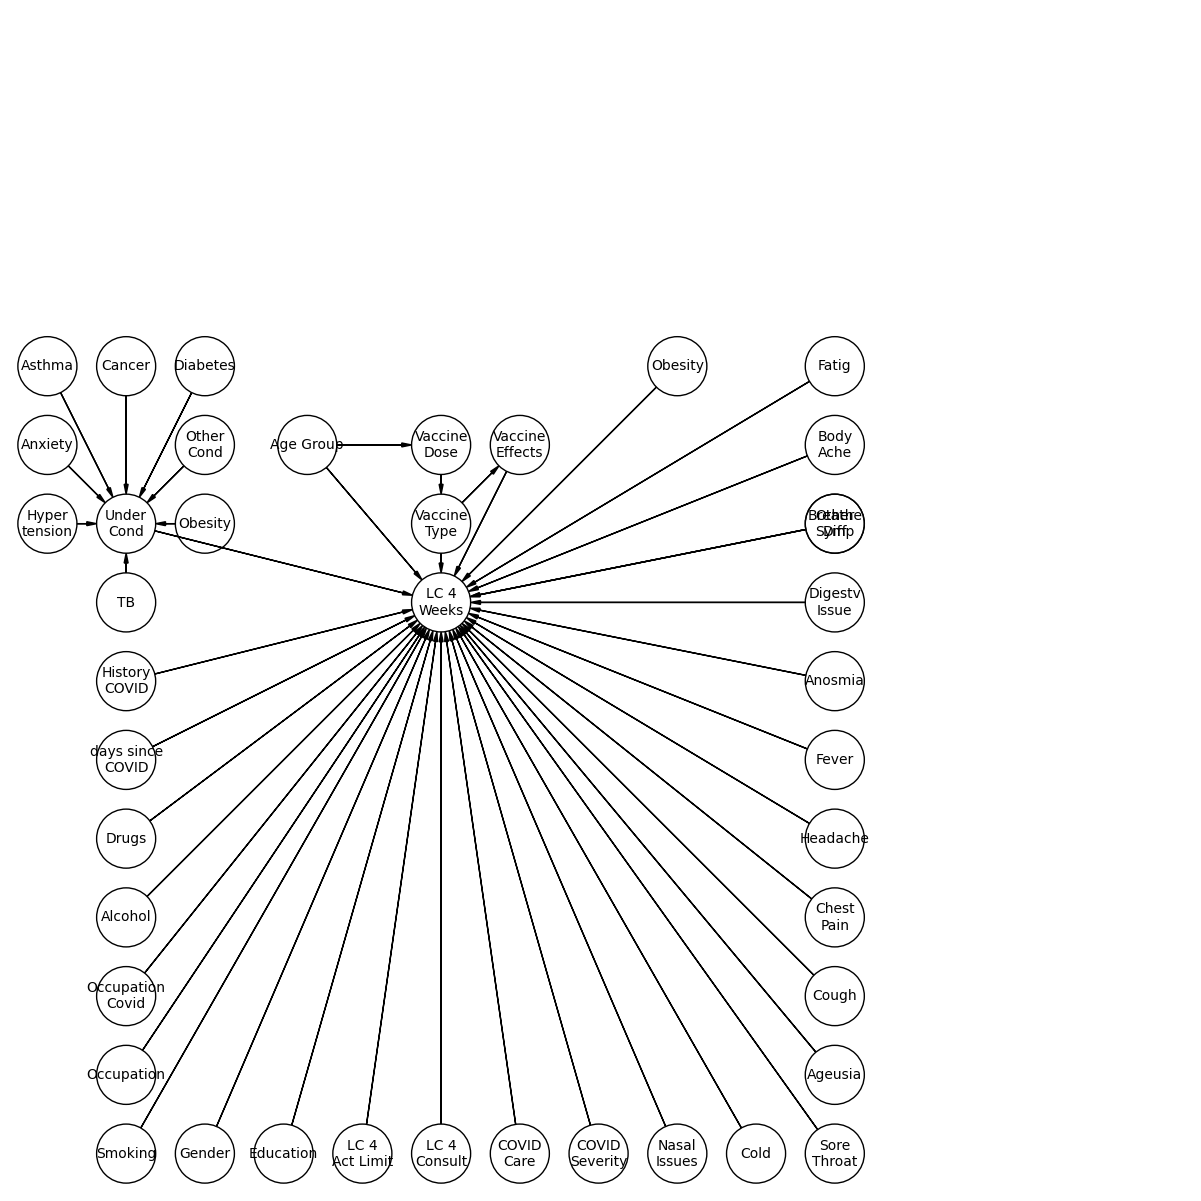

In [ ]:
covidpgm.render()
plt.show()

In [ ]:
# # Create Stratified 5-fold splitter
# # Assuming you have a target column for stratification, e.g., 'target_column'
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# for fold, (train_idx, _) in enumerate(skf.split(longcovid1, longcovid1['longcovid_six'])):
#     # We only use the train index to get each chunk since we're not actually doing cross-validation here
#     chunk = longcovid1.iloc[train_idx]
#     chunk.to_csv(f"longcovid1_part{fold + 1}.csv", index=False)


In [ ]:
bn_structure = [
    ('Age_group', 'longcovid_four'),
    ('sex', 'longcovid_four'),
    #('education', 'longcovid_six'),
    #('smoking', 'longcovid_six'),
    ('alcohol', 'longcovid_four'),
    #('drugs', 'longcovid_six'),
    ('occupation', 'longcovid_four'),
    ('occupation_covid', 'longcovid_four'),
    ('past_history_covid', 'longcovid_four'),
    #('date_diff_four_4_classes', 'longcovid_six'),

    ('hypertension', 'under_cond'),
    #('anxiety', 'under_cond'),
    ('asthma', 'under_cond'),
    #('cancer', 'under_cond'),
    ('diabetes', 'under_cond'),
    ('other_medical', 'under_cond'),
    ('obesity', 'under_cond'),
    #('tb', 'under_cond'),
    ('under_cond', 'longcovid_four'),

    ('vaccine_dose', 'vaccine_type'),
    ('vaccine_type', 'longcovid_four'),
    ('vaccine_type', 'vaccine_effect'),
    ('vaccine_effect', 'longcovid_four'),

    #('lc_fatigue_four', 'longcovid_six'),
    #('lc_cough_four', 'longcovid_six'),
    #('lc_headache_four', 'longcovid_six'),
    #('lc_breathing_four', 'longcovid_six'),
    #('lc_taste_four', 'longcovid_six'),
    #('lc_smell_four', 'longcovid_six'),
    #('lc_brainfog_four', 'longcovid_six'),
    #('lc_chestpain_four', 'longcovid_six'),
    #('lc_palpitation_four', 'longcovid_six'),
    #('lc_anxiety_four', 'longcovid_six'),
    #('lc_fever_four', 'longcovid_six'),
    #('lc_other_four', 'longcovid_six'),

    ('covid_severity', 'longcovid_four'),
    ('covid_care', 'longcovid_four'),
    #('Headache', 'longcovid_four'),
    ('Cough', 'longcovid_four'),
    ('Fever', 'longcovid_four'),
    ('Ageusia', 'longcovid_four'),
    ('Anosmia', 'longcovid_four'),
    ('SoreThroat', 'longcovid_four'),
    #('DigestiveIssues', 'longcovid_four'),
    ('Cold', 'longcovid_four'),
    #('OtherSymptoms', 'longcovid_four'),
    #('Bodyache', 'longcovid_four'),
    ('BreathingDifficulty', 'longcovid_four'),
    ('NasalIssues', 'longcovid_four'),
    ('Fatigue', 'longcovid_four'),
    #('ChestPain', 'longcovid_four'),

    #('lc_activitylimit_four', 'longcovid_four'),
    #('lc_activitylimit_four', 'longcovid_six'),
    #('lc_consultation_four', 'longcovid_four'),
    #('lc_consultation_four', 'longcovid_six'),
    #('Age_group','vaccine_dose')
]

In [ ]:
bnmodel1=BayesianNetwork(bn_structure)

In [ ]:
longcovid1=longcovid.loc[:, ['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma','occupation',
                              'covid_severity', 'covid_care', 'longcovid_four',
                              'other_medical','hypertension','past_history_covid',
                                  'NasalIssues','Cough','Ageusia','Cold','Fatigue',
                              'Fever',  'BreathingDifficulty', 'Anosmia', 'SoreThroat','vaccine_dose',
                              'vaccine_effect','vaccine_type', 'Age_group', 'under_cond','obesity']]

In [ ]:
# Get the variable names from the Bayesian network model
variable_names_in_model = set(bnmodel1.nodes)

# Get the column names from your training data
column_names_in_data = set(longcovid1.columns)

# Identify missing columns (in the model but not in the data)
missing_columns = variable_names_in_model - column_names_in_data

# Identify excessive columns (in the data but not in the model)
excessive_columns = column_names_in_data - variable_names_in_model

# Print the results
print("Missing Columns (in the model but not in the data):", missing_columns)
print("Excessive Columns (in the data but not in the model):", excessive_columns)

Missing Columns (in the model but not in the data): set()
Excessive Columns (in the data but not in the model): set()


In [ ]:

# Combine the columns for stratification
# Combine the columns for stratification
#longcovid1['stratify_col'] = (longcovid1['vaccine_effect'].astype(str) + "_" +
                              #longcovid1['longcovid_four'].astype(str))

# Perform stratified sampling based on the combined column
training_data, testing_data = train_test_split(longcovid1, test_size=0.35, random_state=42,
#stratify=longcovid1['stratify_col']
                                               )

# Drop the combined column after splitting
#training_data = training_data.drop(columns=['stratify_col'])
#testing_data = testing_data.drop(columns=['stratify_col'])



In [ ]:



Hypercpd = TabularCPD(variable='hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%

#cancercpd = TabularCPD(variable='cancer',
                       #variable_card=2,
                       #values=[[.43], [.57]]) #union from AIHW 19.6%
age_group_states = [1,2,3,4]
Agecpd = TabularCPD(variable='Age_group',
                       variable_card=4,
                       values=[[0.305], [0.282], [0.242], [0.171]], state_names={'Age_group':age_group_states})



sexcpd = TabularCPD(variable='sex',
                       variable_card=2,
                       values=[[.5021], [.4979]])

Coldcpd = TabularCPD(variable='Cold',
                       variable_card=2,
                       values=[[.125], [.875]]) #20% on winters
Coughcpd = TabularCPD(variable='Cough',
                       variable_card=2,
                       values=[[.1], [.9]]) #15% on winters


BDcpd = TabularCPD(variable='BreathingDifficulty',
                       variable_card=2,
                       values=[[.075], [.925]]) #
#Headachecpd = TabularCPD(variable='Headache',
                       #variable_card=2,
                       #values=[[.15], [.85]])
Anosmiacpd = TabularCPD(variable='Anosmia',
                       variable_card=2,
                       values=[[.03], [.97]])
Ageusiacpd = TabularCPD(variable='Ageusia',
                       variable_card=2,
                       values=[[.02], [.98]])

obescpd = TabularCPD(variable='obesity',
                       variable_card=2,
                       values=[[.687], [.313]])


bnmodel1.add_cpds(Hypercpd,Diabcpd,Asthmacpd,sexcpd,Coldcpd ,Coughcpd,BDcpd,Anosmiacpd,Ageusiacpd,obescpd,Agecpd)

In [ ]:
longcovid2=longcovid1.loc[:, [ 'occupation_covid', 'alcohol','occupation',
                              'covid_severity', 'covid_care', 'longcovid_four',
                              'other_medical','past_history_covid',
                                 'NasalIssues',
                              'Fever','Fatigue',  'vaccine_dose',
                              'vaccine_effect','vaccine_type', 'under_cond','SoreThroat']]

In [ ]:
# Bayesian Estimation on the Training Data
estimator = BayesianEstimator(bnmodel1, training_data)
columns = longcovid2.columns.tolist()
for column in columns:
    cpd = estimator.estimate_cpd(column)
    bnmodel1.add_cpds(cpd)

In [ ]:
# 1. Gather States from CPDs
cpd_states = {cpd.variable: set(cpd.state_names[cpd.variable]) for cpd in bnmodel1.get_cpds()}

# 2. Gather States from Data
data_states_train = {column: set(training_data[column].unique()) for column in training_data.columns}
data_states_test = {column: set(testing_data[column].unique()) for column in testing_data.columns}

# 3. Compare
mismatches_train = {column: data_states_train[column] - cpd_states.get(column, set()) for column in data_states_train}
mismatches_test = {column: data_states_test[column] - cpd_states.get(column, set()) for column in data_states_test}

print("Mismatches in Training Data:", mismatches_train)
print("Mismatches in Testing Data:", mismatches_test)

Mismatches in Training Data: {'sex': set(), 'occupation_covid': set(), 'alcohol': set(), 'diabetes': set(), 'asthma': set(), 'occupation': set(), 'covid_severity': set(), 'covid_care': set(), 'longcovid_four': set(), 'other_medical': set(), 'hypertension': set(), 'past_history_covid': set(), 'NasalIssues': set(), 'Cough': set(), 'Ageusia': set(), 'Cold': set(), 'Fatigue': set(), 'Fever': set(), 'BreathingDifficulty': set(), 'Anosmia': set(), 'SoreThroat': set(), 'vaccine_dose': set(), 'vaccine_effect': set(), 'vaccine_type': set(), 'Age_group': set(), 'under_cond': set(), 'obesity': set()}
Mismatches in Testing Data: {'sex': set(), 'occupation_covid': set(), 'alcohol': set(), 'diabetes': set(), 'asthma': set(), 'occupation': set(), 'covid_severity': set(), 'covid_care': set(), 'longcovid_four': set(), 'other_medical': set(), 'hypertension': set(), 'past_history_covid': set(), 'NasalIssues': set(), 'Cough': set(), 'Ageusia': set(), 'Cold': set(), 'Fatigue': set(), 'Fever': set(), 'Breat

In [ ]:
# longcovid_six_cpd = bnmodel1.get_cpds('longcovid_six')

# # Access the values of the CPD
# cpd_values = longcovid_six_cpd.values

# # Print the CPD values
# print(cpd_values)


In [ ]:
# # Extract CPDs from bnmodel1
# cpds = bnmodel1.get_cpds()

# # Convert each CPD to a string and collect them in a list
# cpd_strings = [str(cpd) for cpd in cpds]

# # Join the CPD strings with a separator and write to a file
# filename = "bnmodel1_cpds.txt"
# with open(filename, "w") as file:
#     file.write("\n\n=========================\n\n".join(cpd_strings))

In [ ]:
X_train = training_data.drop(columns=['longcovid_four'])
y_train = training_data['longcovid_four']

columns_with_2 = X_train.columns[X_train.isin([1]).any()].tolist()
print(columns_with_2)

columns_with_few_2s = {col: X_train[col].value_counts().get(2, 0) for col in X_train.columns}
columns_with_few_2s = {col: count for col, count in columns_with_few_2s.items() if count > 0 and count < 5}
print(columns_with_few_2s)


['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma', 'occupation', 'covid_severity', 'covid_care', 'other_medical', 'hypertension', 'past_history_covid', 'NasalIssues', 'Cough', 'Ageusia', 'Cold', 'Fatigue', 'Fever', 'BreathingDifficulty', 'Anosmia', 'SoreThroat', 'vaccine_dose', 'vaccine_effect', 'vaccine_type', 'Age_group', 'under_cond', 'obesity']
{'covid_severity': 3, 'vaccine_effect': 2}


In [ ]:
#Split testing data into features and target
X_test = testing_data.drop(columns=['longcovid_four'])
y_test = testing_data['longcovid_four']

columns_with_2 = X_test.columns[X_test.isin([1]).any()].tolist()
print(columns_with_2)

columns_with_few_2s = {col: X_test[col].value_counts().get(2, 0) for col in X_test.columns}
columns_with_few_2s = {col: count for col, count in columns_with_few_2s.items() if count > 0 and count < 5}
print(columns_with_few_2s)


['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma', 'occupation', 'covid_severity', 'covid_care', 'other_medical', 'hypertension', 'past_history_covid', 'NasalIssues', 'Cough', 'Ageusia', 'Cold', 'Fatigue', 'Fever', 'BreathingDifficulty', 'Anosmia', 'SoreThroat', 'vaccine_dose', 'vaccine_effect', 'vaccine_type', 'Age_group', 'under_cond', 'obesity']
{'covid_severity': 1, 'vaccine_effect': 1}


In [ ]:
X_test.shape

(171, 26)

In [ ]:
# # Select a row from X_test where vaccine_effect is 1
# selected_row = X_test[X_test['vaccine_effect'] == 1].iloc[0]

# # Create the evidence dictionary for the selected row
# evidence = {k: int(v) for k, v in selected_row.to_dict().items() if k != 'longcovid_six'}

# # Output the evidence to inspect
# evidence

In [ ]:
# # Select a row from X_test where vaccine_effect is 1
# #pdb.set_trace()
# selected_row = X_test[X_test['vaccine_effect'] == 0].iloc[0]

# # Create the evidence dictionary for the selected row
# evidence = {k: int(v) for k, v in selected_row.to_dict().items() if k != 'longcovid_six'}

# # Query the Bayesian network with the evidence
# result = infer.query(['longcovid_six'], evidence=evidence)
# result

In [ ]:
# # List of columns that need to be converted to strings
# columns_to_convert = testing_data.columns.tolist()  # This converts all columns; you can specify a subset if needed

# for col in columns_to_convert:
#     testing_data[col] = testing_data[col].astype(str)

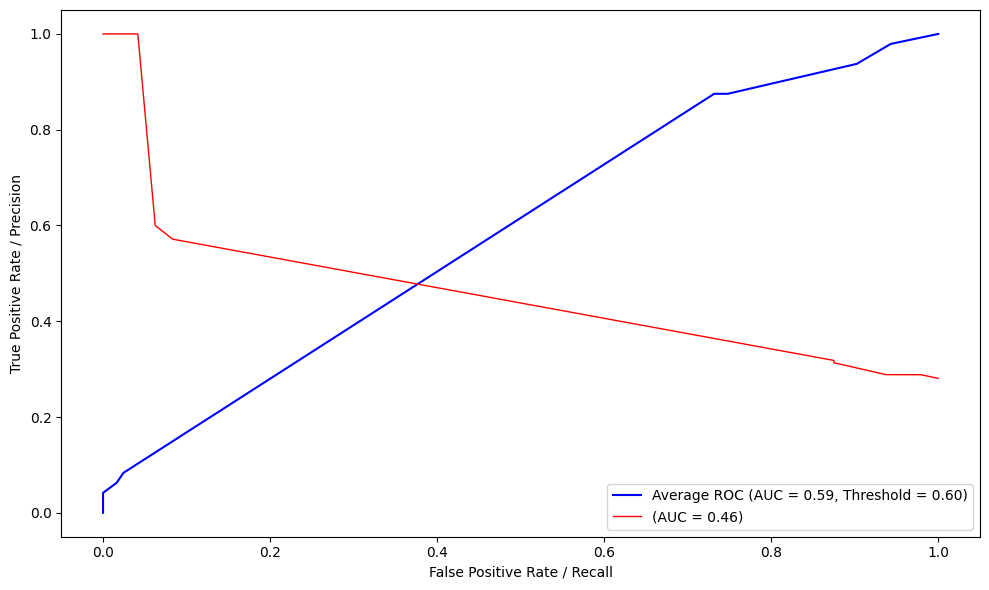

In [ ]:
# Predictions using the Bayesian network


infer = VariableElimination(bnmodel1)
p = 0.6

# Modified predictions code with string conversion for evidence values
predictions = [
    infer.query(['longcovid_four'],
                evidence={k: int(v) for k, v in row.to_dict().items() if k != 'longcovid_four'}).values[1]
    for _, row in testing_data.iterrows()
]


newpred = [1 if pred >= p else 0 for pred in predictions]
accuracy = accuracy_score(y_test, newpred)
precision = precision_score(y_test, newpred)


recall = recall_score(y_test, newpred)


tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
specificity = tn / (tn + fp)


fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
pr_auc = auc(recall_curve, precision_curve)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
pr_auc = auc(recall_curve, precision_curve)




plt.figure(figsize=(10, 6))
plt.plot(fpr,tpr, color='b', label=f'Average ROC (AUC = {roc_auc:.2f}, Threshold = {p:.2f})')
#plt.fill_between(fpr, tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2)
plt.plot(recall_curve, precision_curve, lw=1,color='r', label=f'(AUC = {pr_auc:.2f})')
#plt.fill_between(recall, precision - std_precision, mean_precision + std_precision, color='r', alpha=0.2)

plt.xlabel('False Positive Rate / Recall')
plt.ylabel('True Positive Rate / Precision')
#plt.title(f'ROC and PR Curve for {method}')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


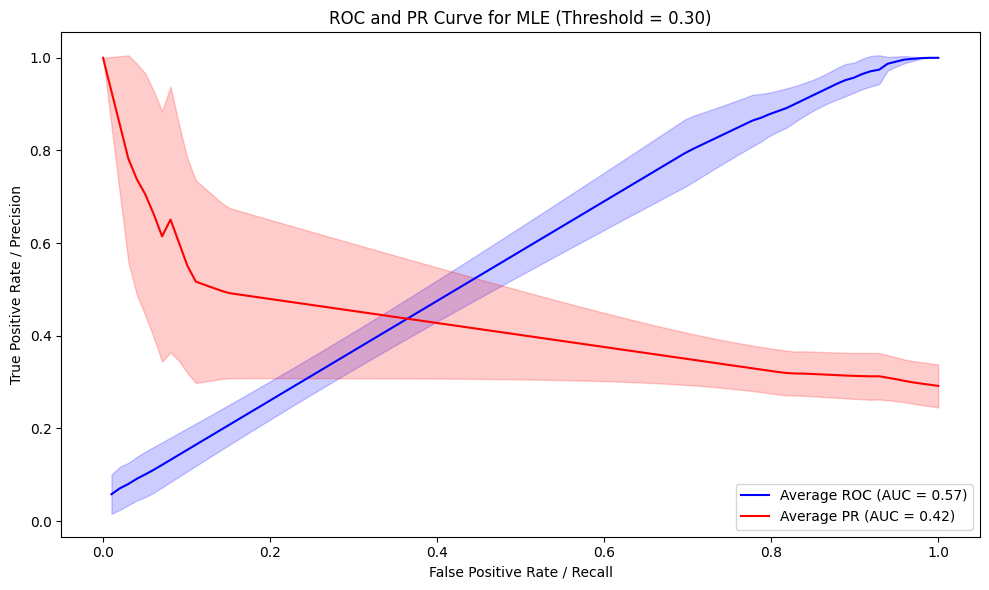

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


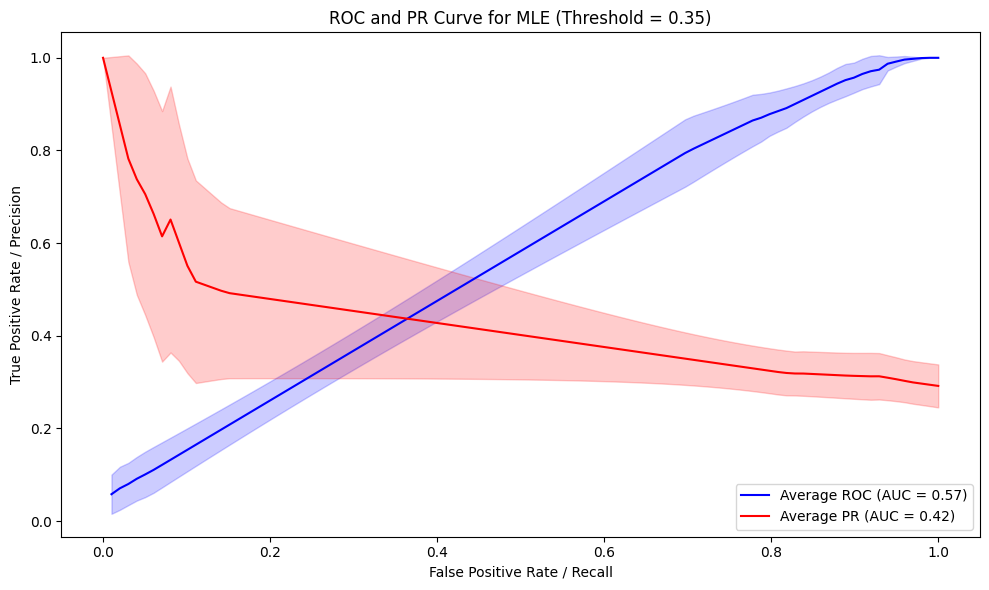

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


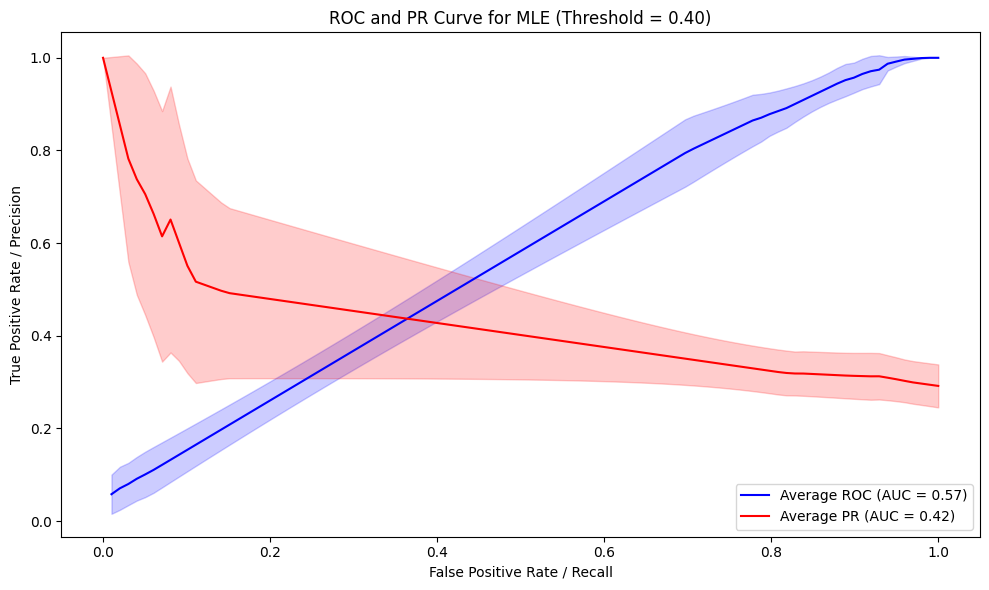

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


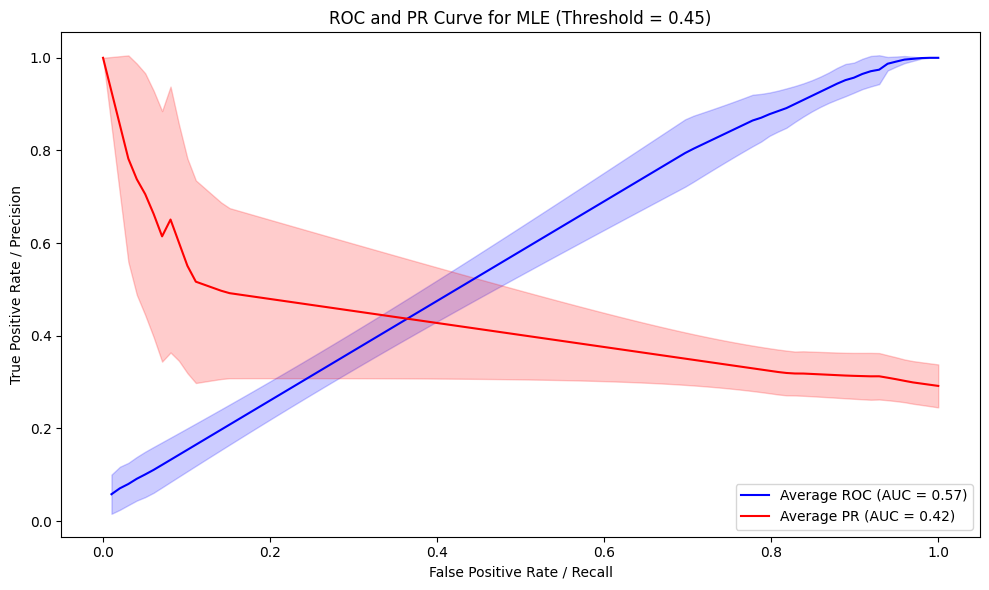

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


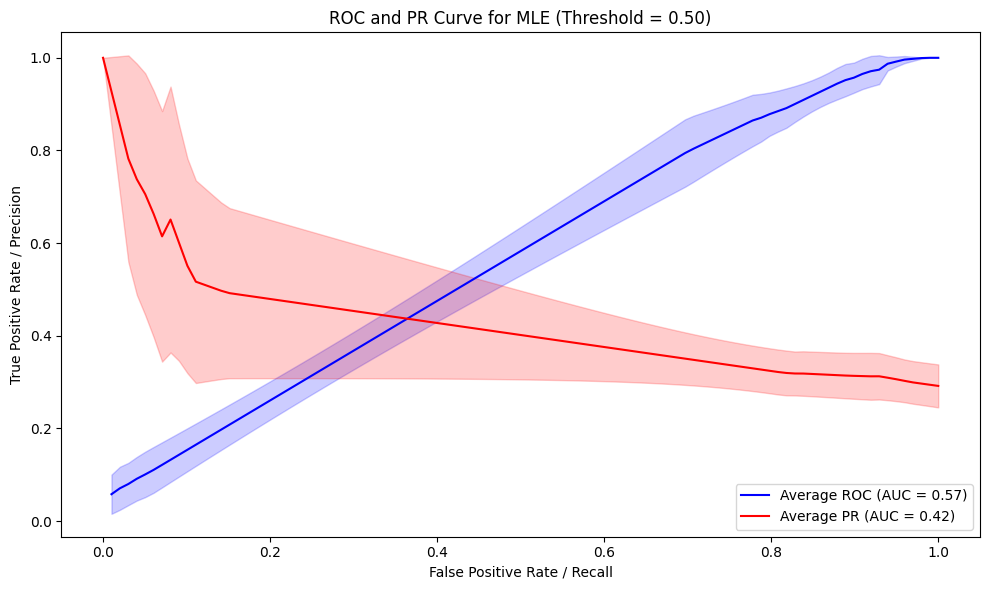

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


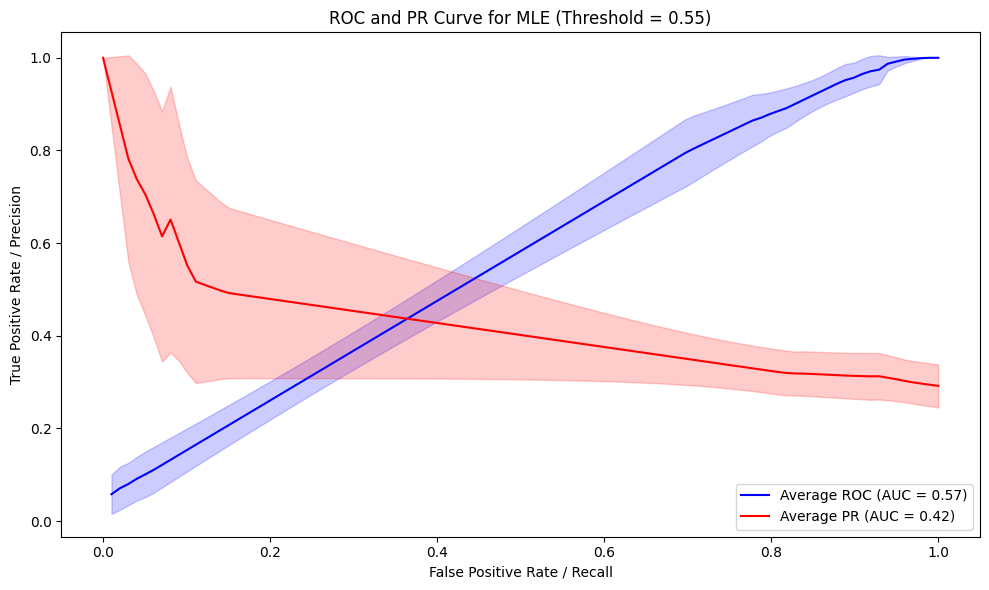

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


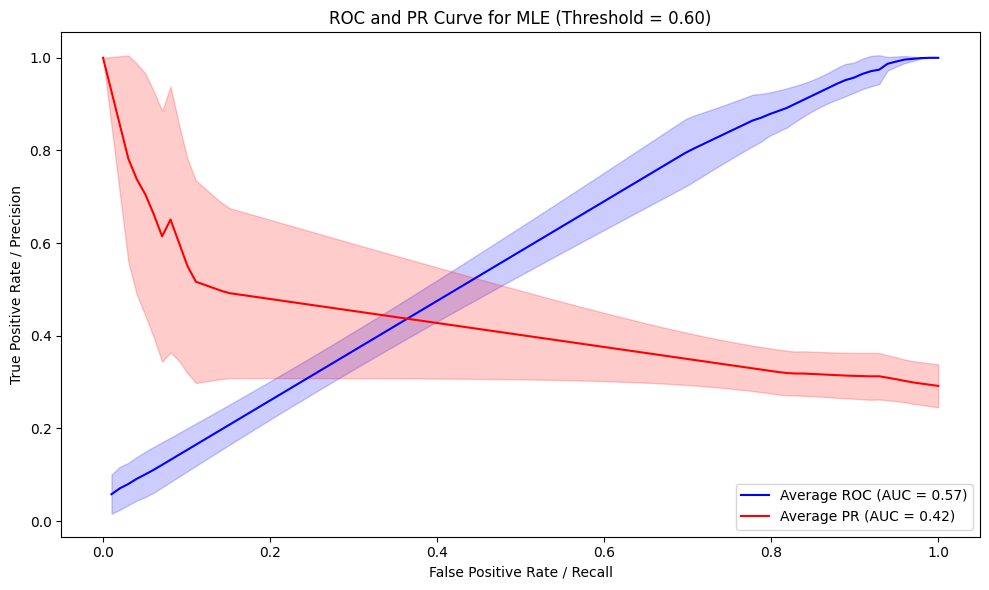

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


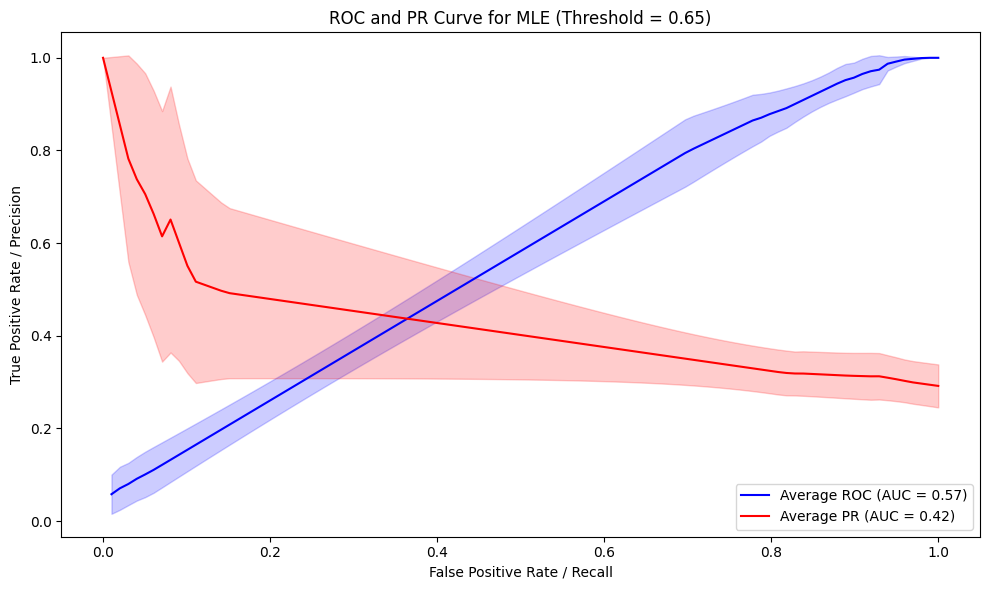

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


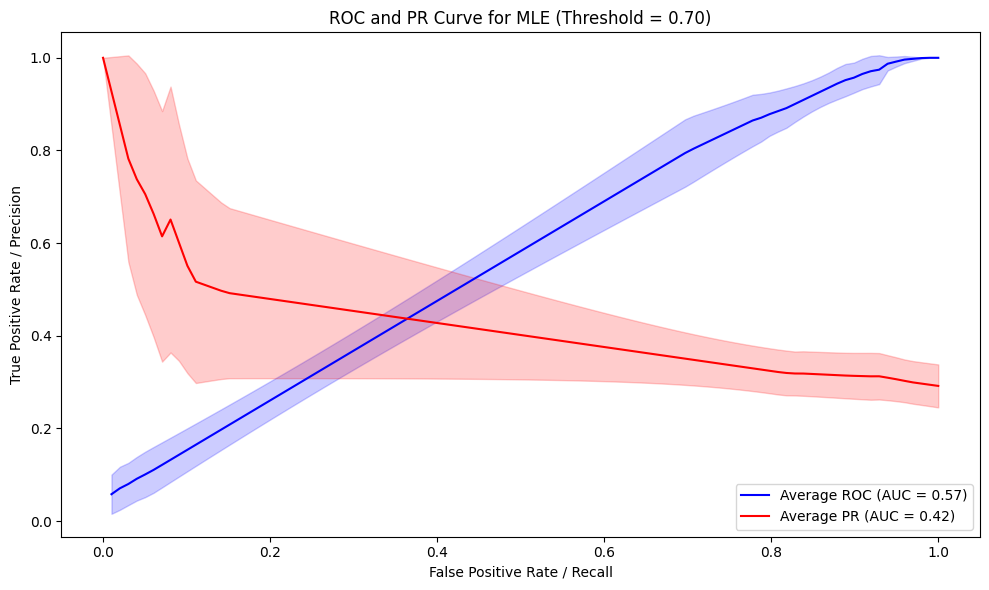

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


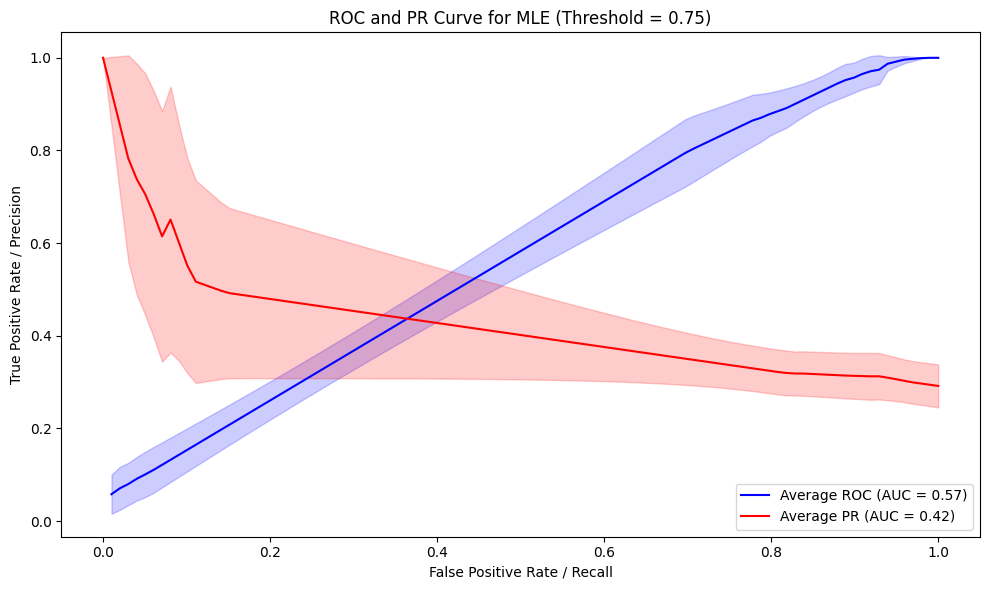

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


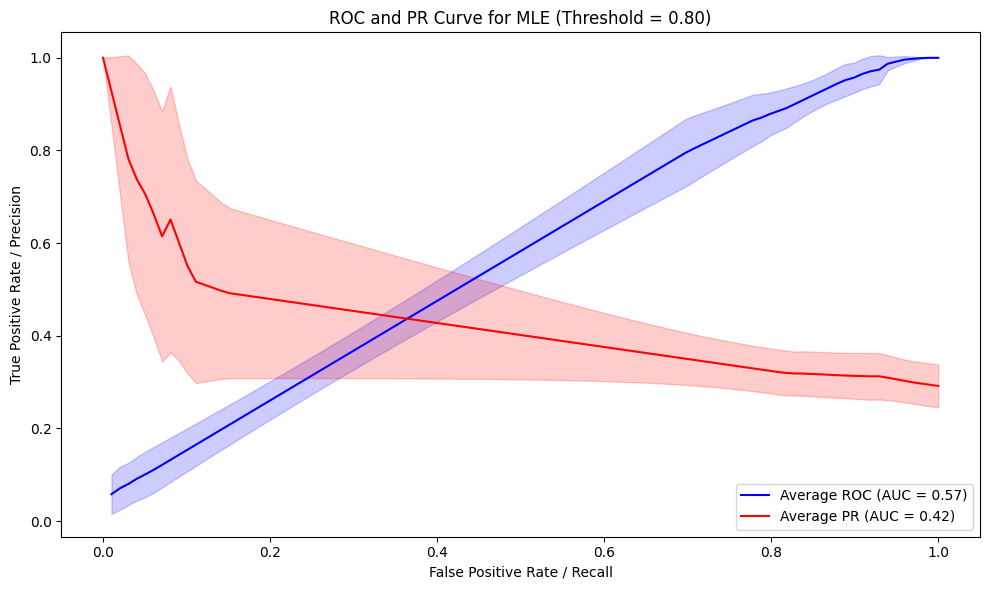

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


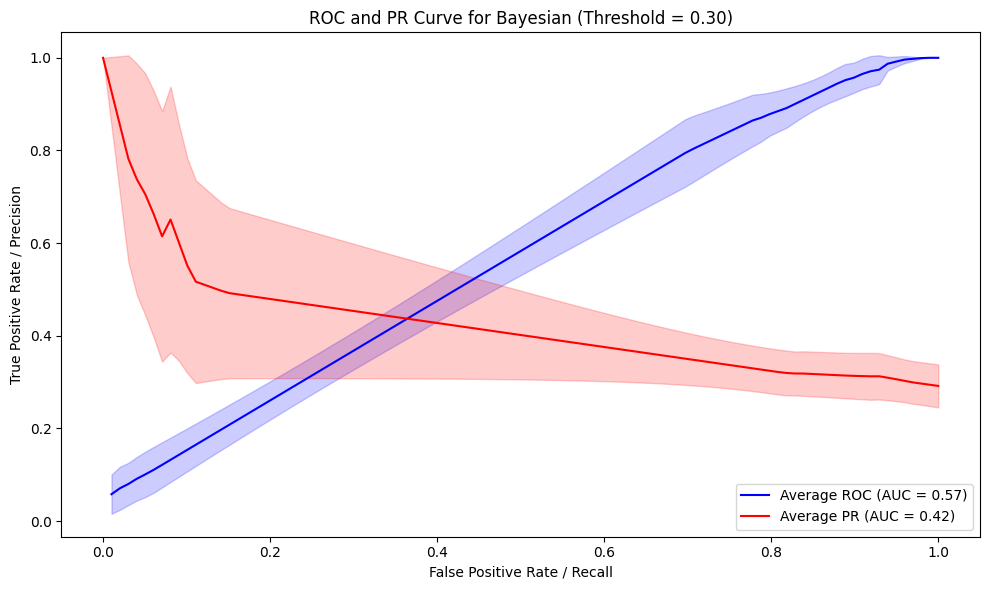

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


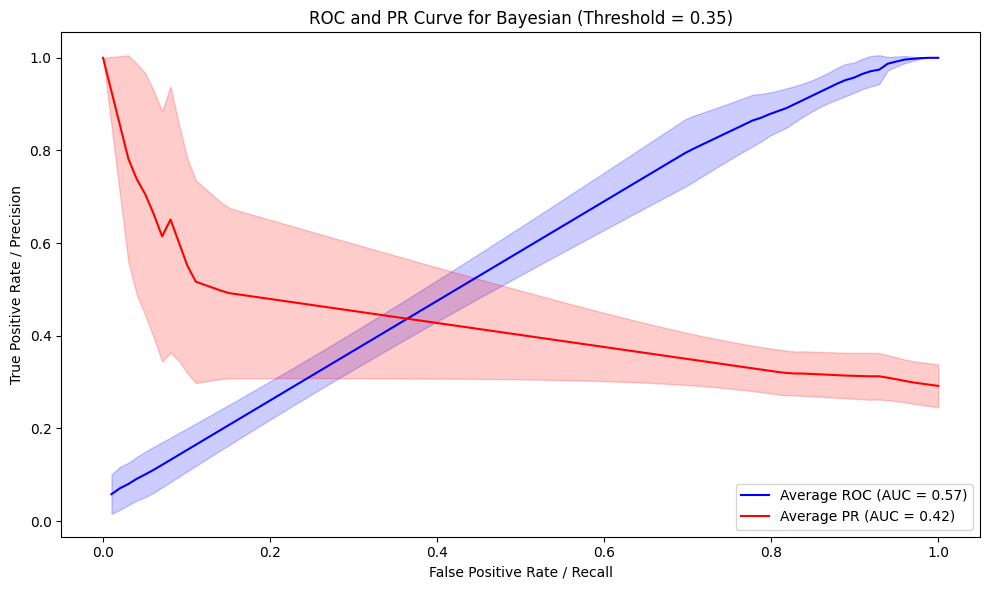

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


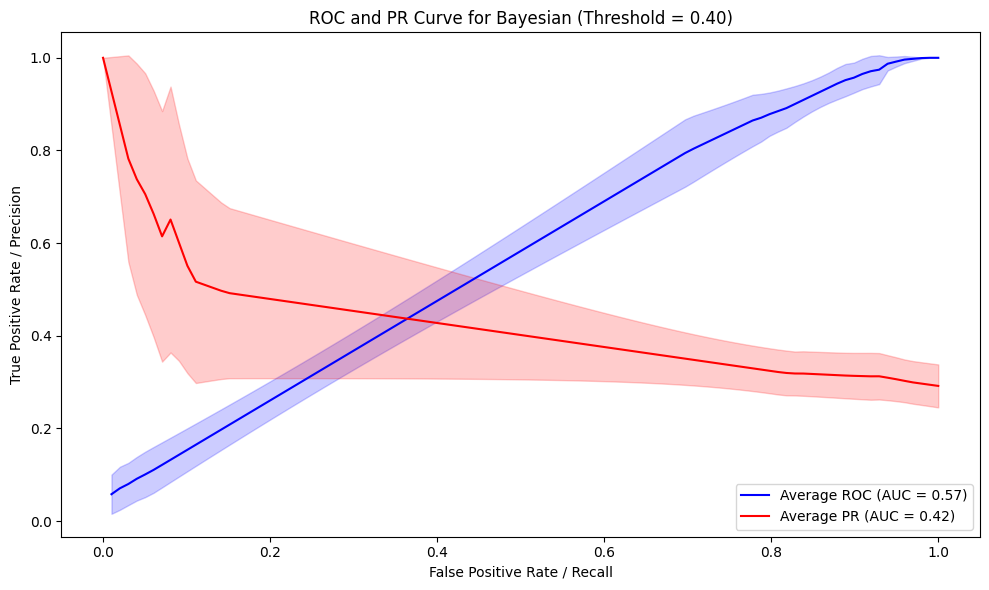

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


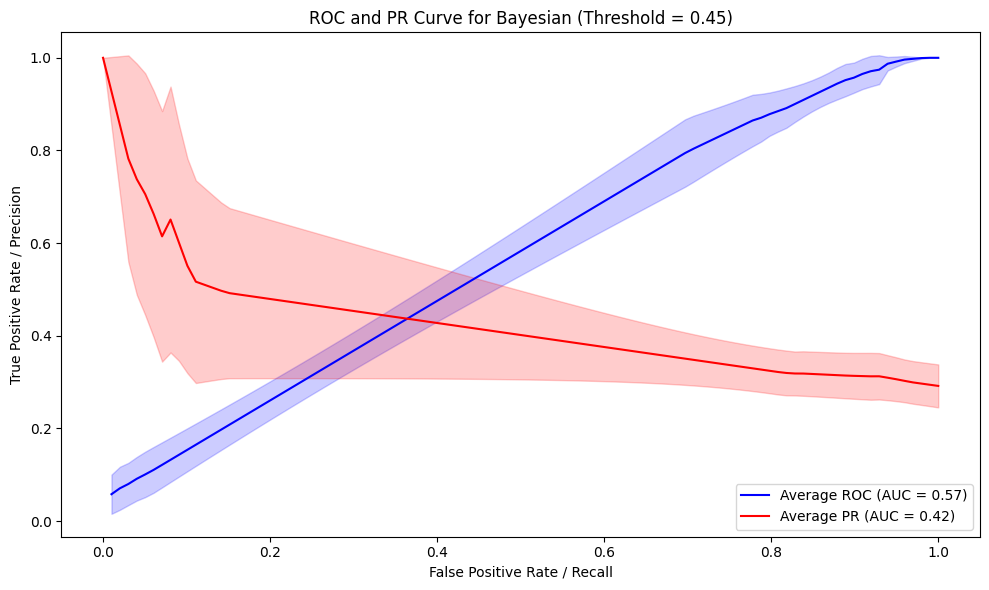

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


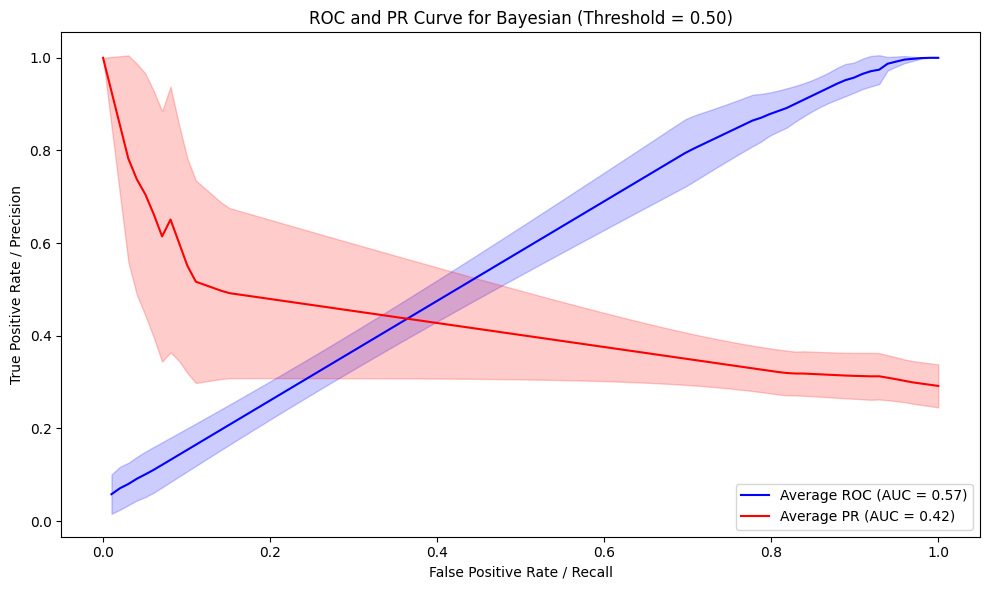

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


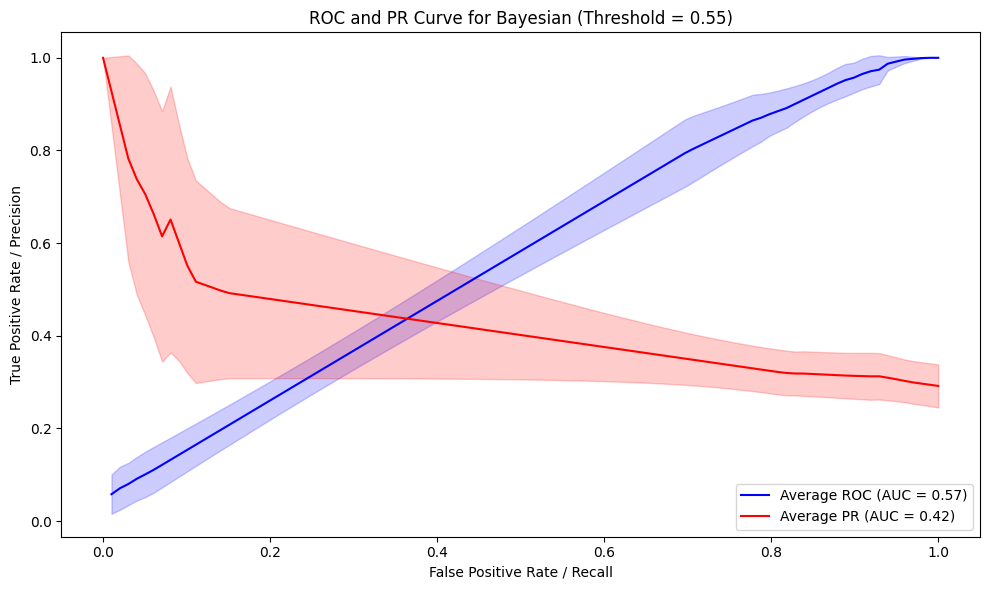

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


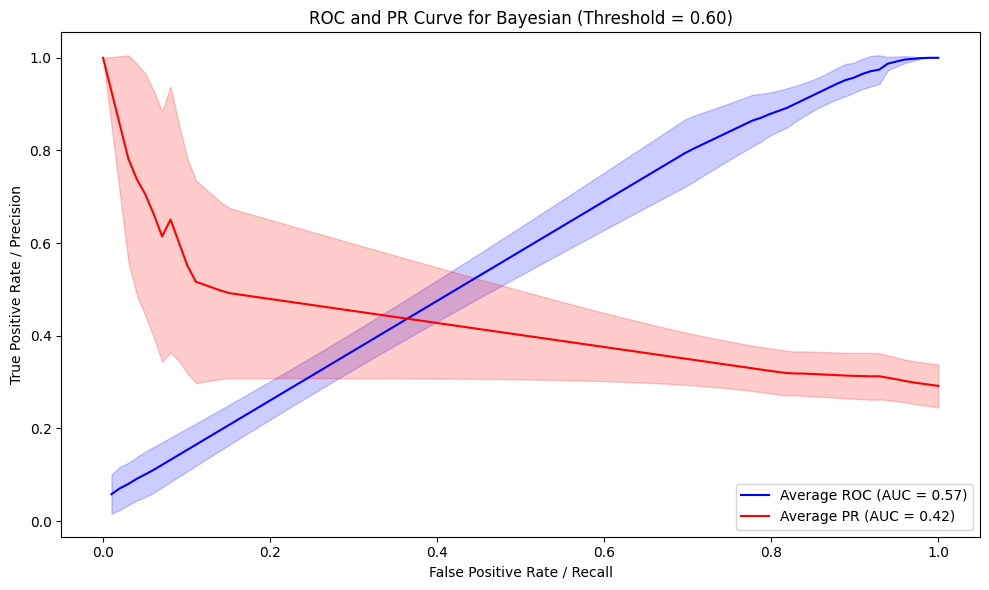

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


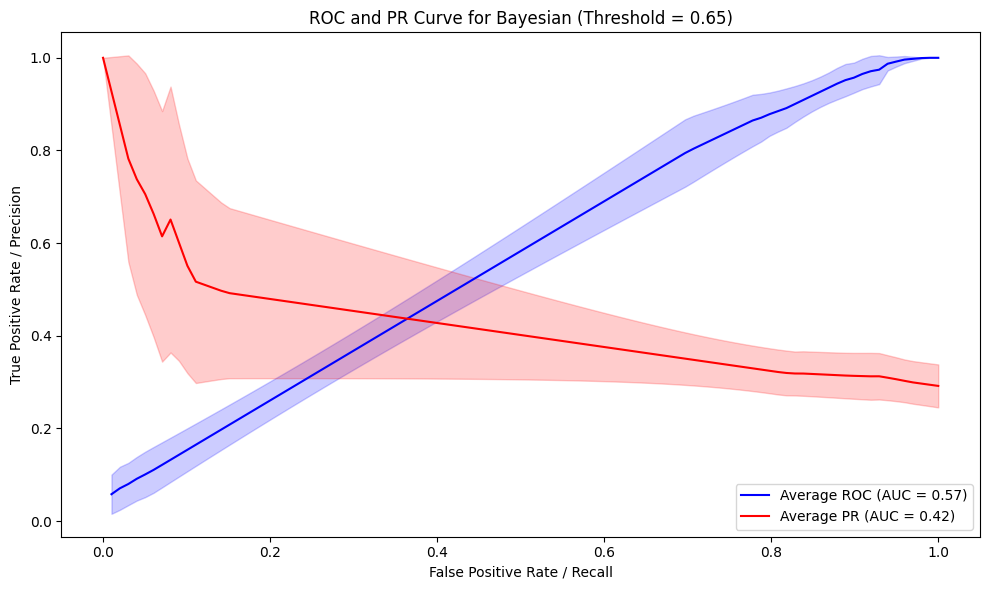

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


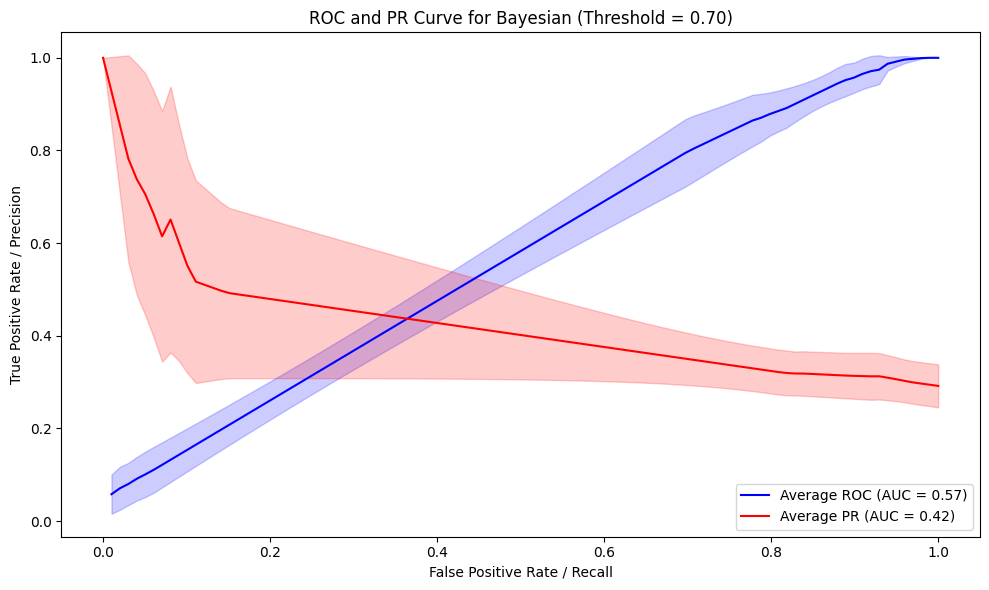

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


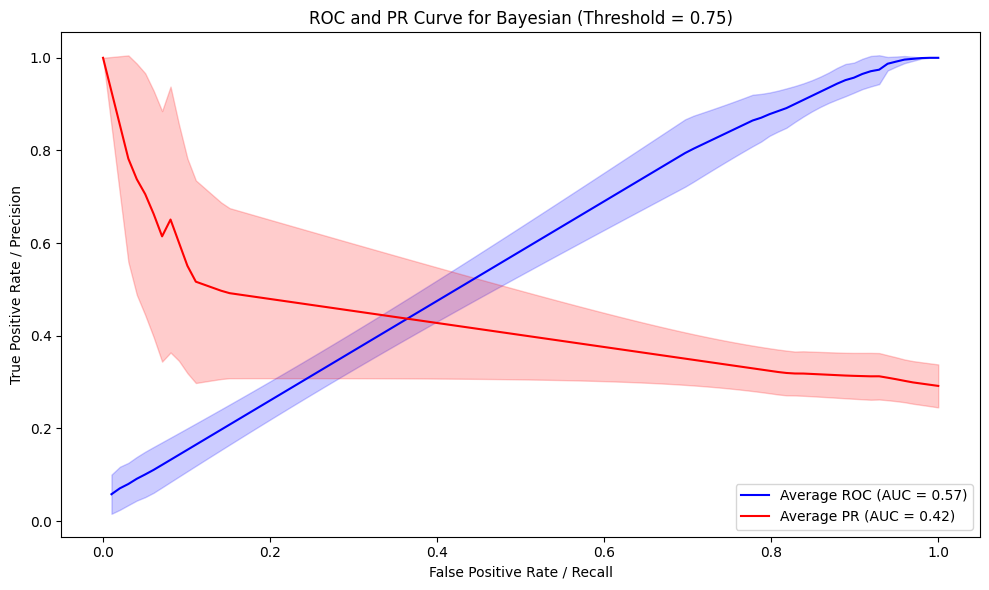

/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


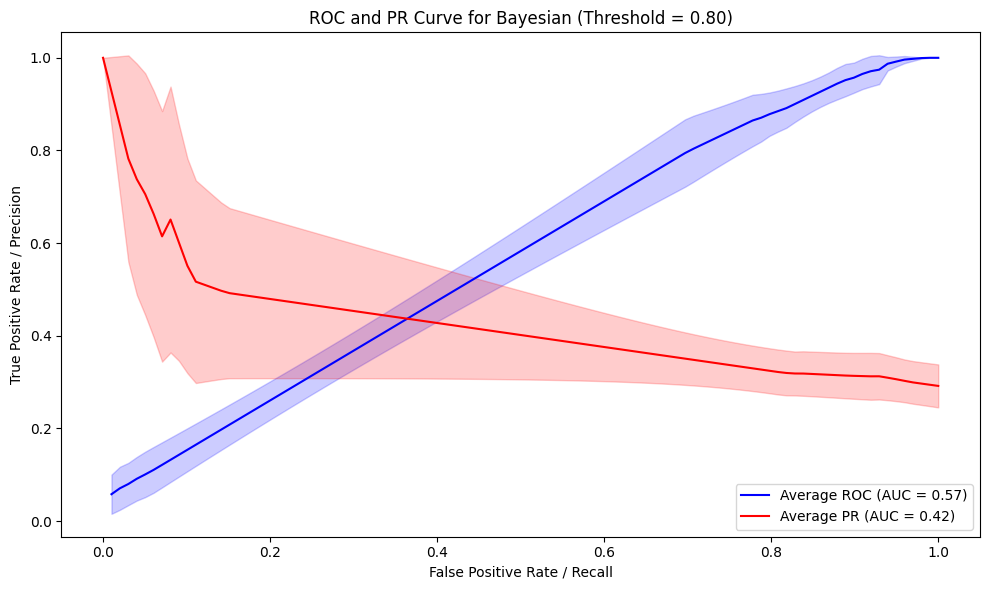

,Threshold,Method,Average Accuracy,Average ROC AUC,Average PR AUC,Average Precision,Average Recall,Average F1,Average Specificity,Computation Time (mins)
0,0.30,MLE,0.414728,0.56972,0.419457,0.316050,0.868245,0.461584,0.227804,1.374951
1,0.35,MLE,0.418830,0.56972,0.419457,0.317142,0.861102,0.461527,0.236851,1.357865
2,0.40,MLE,0.418830,0.56972,0.419457,0.317142,0.861102,0.461527,0.236851,1.357856
3,0.45,MLE,0.418830,0.56972,0.419457,0.317142,0.861102,0.461527,0.236851,1.354350
4,0.50,MLE,0.418830,0.56972,0.419457,0.317142,0.861102,0.461527,0.236851,1.354487
5,0.55,MLE,0.704271,0.56972,0.419457,0.471429,0.096680,0.159991,0.953724,1.352059
6,0.60,MLE,0.704271,0.56972,0.419457,0.471429,0.096680,0.159991,0.953724,1.354517
7,0.65,MLE,0.704271,0.56972,0.419457,0.471429,0.096680,0.159991,0.953724,1.353791
8,0.70,MLE,0.706312,0.56972,0.419457,0.481429,0.089537,0.150157,0.959321,1.350784
9,0.75,MLE,0.708353,0.56972,0.419457,0.498095,0.089537,0.150649,0.962060,1.355711


In [ ]:
# KFold configuration
from scipy import interpolate
from sklearn.model_selection import KFold

target = 'longcovid_four'
features = longcovid1.drop(columns=['longcovid_four'])
X = longcovid1[features.columns]
y = longcovid1['longcovid_four']


skf = KFold(n_splits=5, shuffle=True, random_state=42)
methods = ["MLE", "Bayesian"]
thresholds = np.arange(0.3, 0.85, 0.05)
results = {
    'Threshold': [],
    'Method': [],
    'Average Accuracy': [],
    'Average ROC AUC': [],
    'Average PR AUC': [],
    'Average Precision': [],
    'Average Recall': [],
    'Average F1': [],
    'Average Specificity': [],
    'Computation Time (mins)': []
}

for method in methods:
    for p in thresholds:
        start_time = time.time()

        accuracies, roc_aucs, pr_aucs, precisions, recalls, f1_scores, specificities = [], [], [], [], [], [], []
        all_fpr, all_tpr, all_precision, all_recall = [], [], [], []

        for idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            training_data, testing_data = longcovid1.iloc[train_idx], longcovid1.iloc[test_idx]

            estimator = BayesianEstimator(bnmodel1, training_data)
            for column in longcovid1.columns:
                cpd = estimator.estimate_cpd(column)
                bnmodel1.add_cpds(cpd)

            infer = VariableElimination(bnmodel1)
            X_test, y_test = testing_data.drop(columns=['longcovid_four']), testing_data['longcovid_four']
            predictions = [infer.query(['longcovid_four'], evidence=row.to_dict()).values[1] for _, row in X_test.iterrows()]
            newpred = [1 if pred >= p else 0 for pred in predictions]

            accuracy = accuracy_score(y_test, newpred)
            precision = precision_score(y_test, newpred)
            recall = recall_score(y_test, newpred)
            f1 = f1_score(y_test, newpred)
            tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
            specificity = tn / (tn + fp)

            accuracies.append(accuracy)
            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1)
            specificities.append(specificity)

            fpr, tpr, _ = roc_curve(y_test, predictions)
            roc_auc = auc(fpr, tpr)
            all_fpr.append(fpr)
            all_tpr.append(tpr)
            roc_aucs.append(roc_auc)

            precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
            pr_auc = auc(recall_curve, precision_curve)
            all_precision.append(precision_curve)
            all_recall.append(recall_curve)
            pr_aucs.append(pr_auc)

        # Interpolation for ROC and PR curves
        mean_fpr = np.linspace(0, 1, 100)
        mean_tpr = np.mean([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
        std_tpr = np.std([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)

        mean_precision = np.mean([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)
        std_precision = np.std([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)

        # Plotting the average ROC and PR curves with confidence intervals
        plt.figure(figsize=(10, 6))
        plt.plot(mean_fpr, mean_tpr, color='b', label=f'Average ROC (AUC = {np.mean(roc_aucs):.2f})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2)
        plt.plot(mean_fpr, mean_precision, color='r', label=f'Average PR (AUC = {np.mean(pr_aucs):.2f})')
        plt.fill_between(mean_fpr, mean_precision - std_precision, mean_precision + std_precision, color='r', alpha=0.2)

        plt.xlabel('False Positive Rate / Recall')
        plt.ylabel('True Positive Rate / Precision')
        plt.title(f'ROC and PR Curve for {method} (Threshold = {p:.2f})')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

        end_time = time.time()
        elapsed_time = (end_time - start_time) / 60

        results['Threshold'].append(p)
        results['Method'].append(method)
        results['Average Accuracy'].append(np.mean(accuracies))
        results['Average ROC AUC'].append(np.mean(roc_aucs))
        results['Average PR AUC'].append(np.mean(pr_aucs))
        results['Average Precision'].append(np.mean(precisions))
        results['Average Recall'].append(np.mean(recalls))
        results['Average F1'].append(np.mean(f1_scores))
        results['Average Specificity'].append(np.mean(specificities))
        results['Computation Time (mins)'].append(elapsed_time)

results_df = pd.DataFrame(results)
display(results_df)


In [ ]:
from scipy import interpolate


/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_interpolate.py:704: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


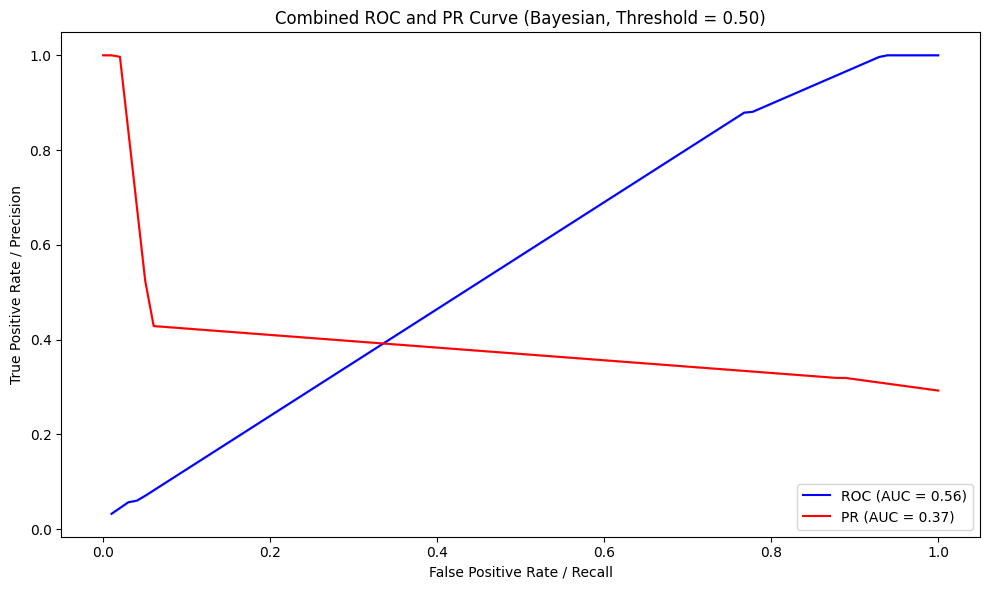

In [ ]:

target="longcovid_four"
X_train, X_test, y_train, y_test = train_test_split(longcovid1, longcovid1[target], test_size=0.35, random_state=42, stratify=longcovid1[target])
threshold = 0.5

all_fpr, all_tpr, all_precision, all_recall = [], [], [], []
fig, ax = plt.subplots(1, figsize=(10, 6))

estimator = BayesianEstimator(bnmodel1, X_train)
for column in longcovid2.columns:
    cpd = estimator.estimate_cpd(column)
    bnmodel1.add_cpds(cpd)

infer = VariableElimination(bnmodel1)
predictions = [infer.query([target], evidence={k: int(v) for k, v in row.to_dict().items() if k != target}).values[1] for _, row in X_test.iterrows()]
newpred = [1 if pred >= threshold else 0 for pred in predictions]

accuracy = accuracy_score(y_test, newpred)
precision = precision_score(y_test, newpred)
recall = recall_score(y_test, newpred)
f1 = f1_score(y_test, newpred)
tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
specificity = tn / (tn + fp)

fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
all_fpr.append(fpr)
all_tpr.append(tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
pr_auc = auc(recall_curve, precision_curve)
all_precision.append(precision_curve)
all_recall.append(recall_curve)


mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
std_tpr = np.std([interpolate.interp1d(fpr, tpr, bounds_error=False, fill_value='extrapolate')(mean_fpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)

mean_precision = np.mean([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)
std_precision = np.std([interpolate.interp1d(recall, precision, bounds_error=False, fill_value='extrapolate')(mean_fpr) for recall, precision in zip(all_recall, all_precision)], axis=0)


ax.plot(mean_fpr, mean_tpr, color='b', label=f'ROC (AUC = {roc_auc:.2f})')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color='b', alpha=0.2)

ax.plot(mean_fpr, mean_precision, color='r', label=f'PR (AUC = {pr_auc:.2f})')
ax.fill_between(mean_fpr, mean_precision - std_precision, mean_precision + std_precision, color='r', alpha=0.2)

ax.set_xlabel('False Positive Rate / Recall')
ax.set_ylabel('True Positive Rate / Precision')
ax.set_title(f'Combined ROC and PR Curve (Bayesian, Threshold = {threshold:.2f})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# infer = VariableElimination(bnmodel1)
# p = 0.5




# for _, row in X_test.iterrows():
#     evidence_dict = {k: str(v) for k, v in row.to_dict().items() if k != 'longcovid_six'}
#     print("Evidence Dictionary:", evidence_dict)

#     longcovid_query = infer.query(['longcovid_six'], evidence=evidence_dict)
#     print("Query Result:", longcovid_query.values[1])

#     prediction = 1 if longcovid_query.values[1] >= p else 0
#     newpred.append(prediction)


In [ ]:
# # Predictions using the Bayesian network
# infer = VariableElimination(bnmodel1)
# p = 0.5

# # Modified predictions code with string conversion for evidence values
# predictions = [
#     infer.query(['longcovid_six'],
#                 evidence={k: str(v) for k, v in row.to_dict().items() if k != 'longcovid_six'}).values[1]
#     for _, row in X_test.iterrows()
# ]
# newpred = [1 if pred >= p else 0 for pred in predictions]

In [ ]:
# Compute metrics
results = pd.DataFrame(columns=['threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity'])

infer = VariableElimination(bnmodel1)

predictions = [infer.query(['longcovid_four'], evidence={k: int(v) for k, v in row.to_dict().items() if k != 'longcovid_four'}).values[1]for _, row in testing_data.iterrows()]
for i in np.arange(0.4,0.9,0.05):
  p =i
  newpred = [1 if pred >= p else 0 for pred in predictions]
  accuracy = accuracy_score(y_test, newpred)

  precision = precision_score(y_test, newpred)
  recall = recall_score(y_test, newpred)
  f1 = f1_score(y_test, newpred)
  tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
  specificity = tn / (tn + fp)


  new_row = pd.DataFrame({
    'threshold':[i],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1': [f1],
    'Specificity': [specificity]})
  results = pd.concat([results, new_row], ignore_index=True)

results

,threshold,Accuracy,Precision,Recall,F1,Specificity
0,0.40,0.438596,0.318182,0.875000,0.466667,0.268293
1,0.45,0.438596,0.318182,0.875000,0.466667,0.268293
2,0.50,0.438596,0.318182,0.875000,0.466667,0.268293
3,0.55,0.725146,0.571429,0.083333,0.145455,0.975610
4,0.60,0.725146,0.571429,0.083333,0.145455,0.975610
5,0.65,0.725146,0.571429,0.083333,0.145455,0.975610
6,0.70,0.725146,0.600000,0.062500,0.113208,0.983740
7,0.75,0.725146,0.600000,0.062500,0.113208,0.983740
8,0.80,0.725146,0.600000,0.062500,0.113208,0.983740
9,0.85,0.725146,0.600000,0.062500,0.113208,0.983740


In [ ]:
longcovid1=longcovid.loc[:, ['sex', 'occupation_covid', 'alcohol', 'diabetes', 'asthma','occupation',
                              'covid_severity', 'covid_care', 'longcovid_four',
                              'other_medical','hypertension','past_history_covid',
                                  'NasalIssues','Cough','Ageusia','Cold','Fatigue',
                              'Fever',  'BreathingDifficulty', 'Anosmia', 'SoreThroat','vaccine_dose',
                              'vaccine_effect','vaccine_type', 'Age_group', 'under_cond','obesity']]

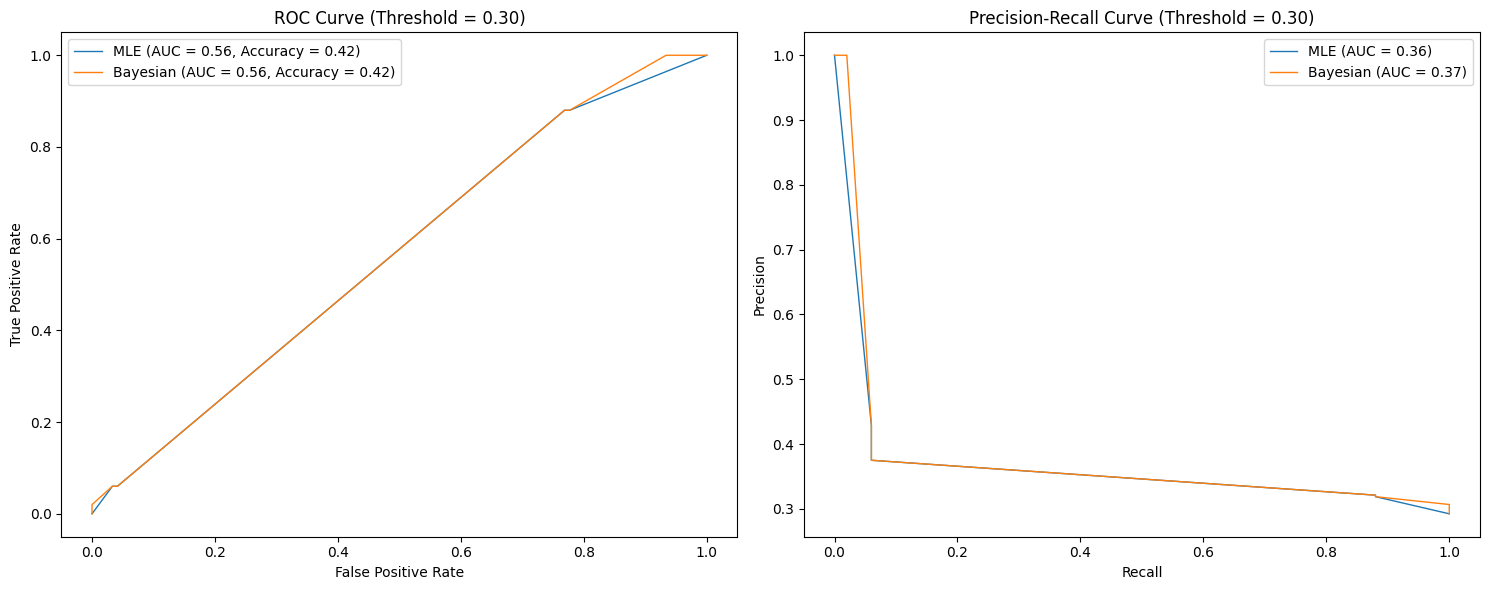

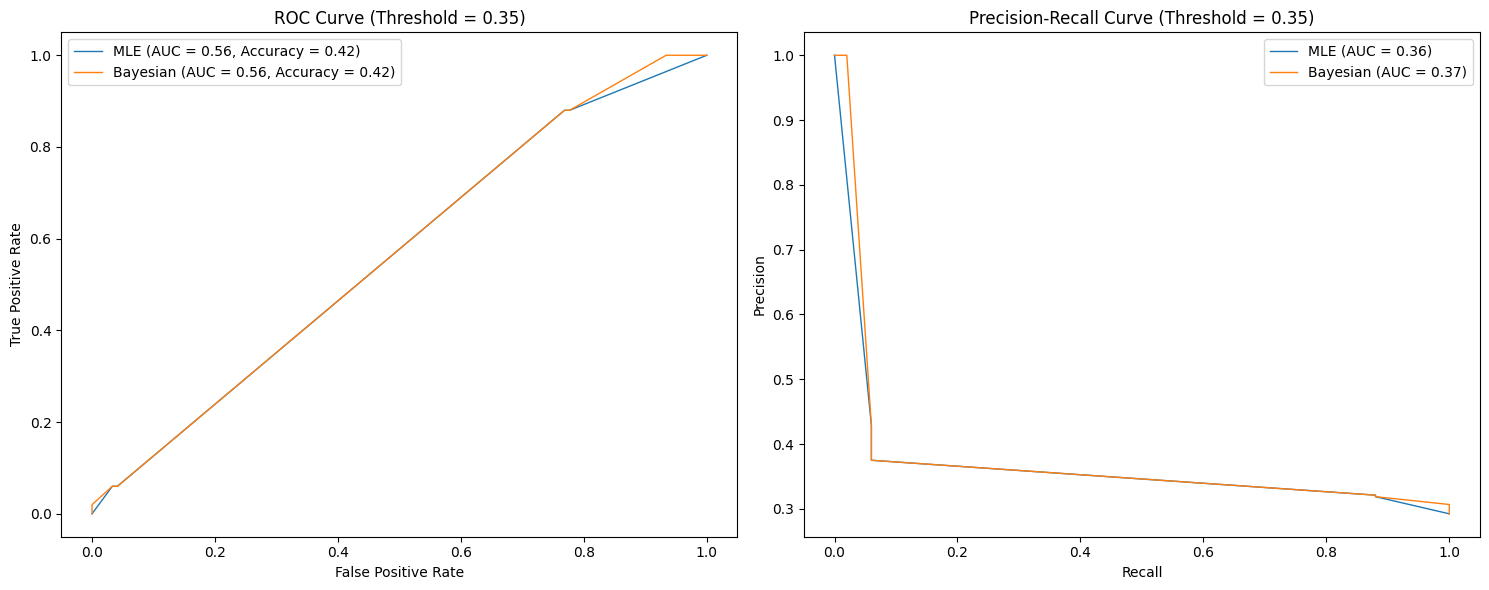

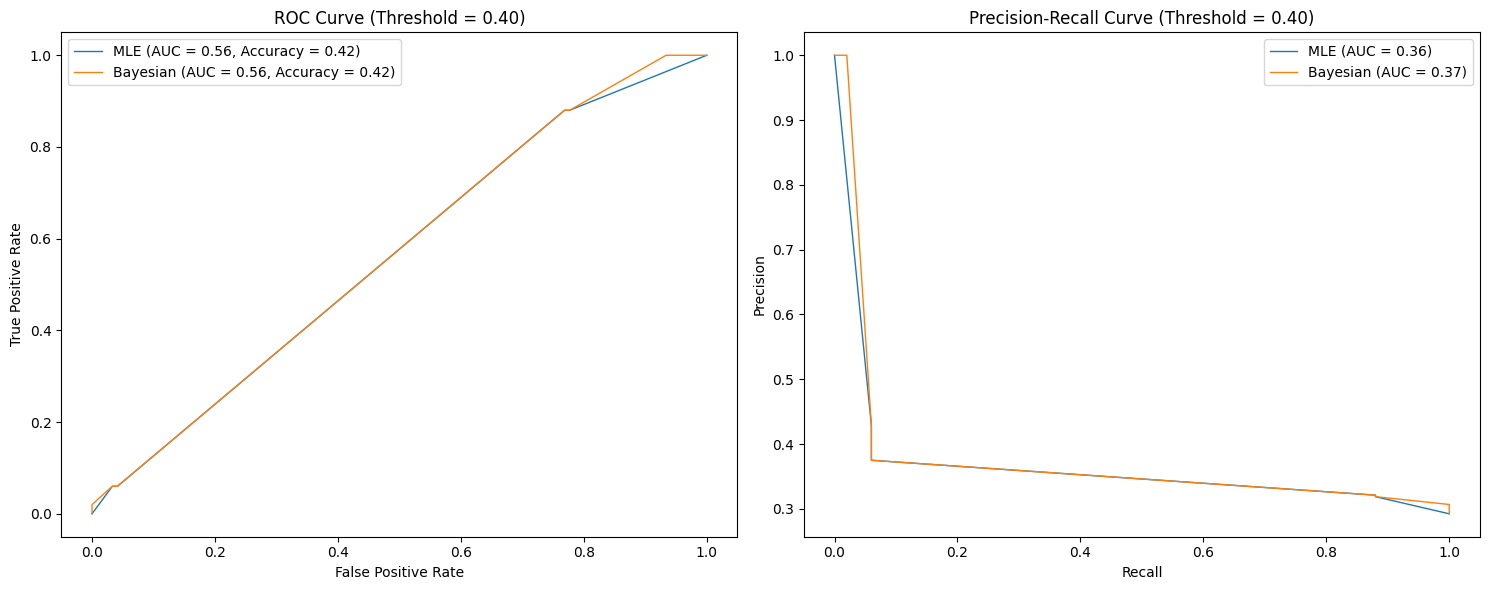

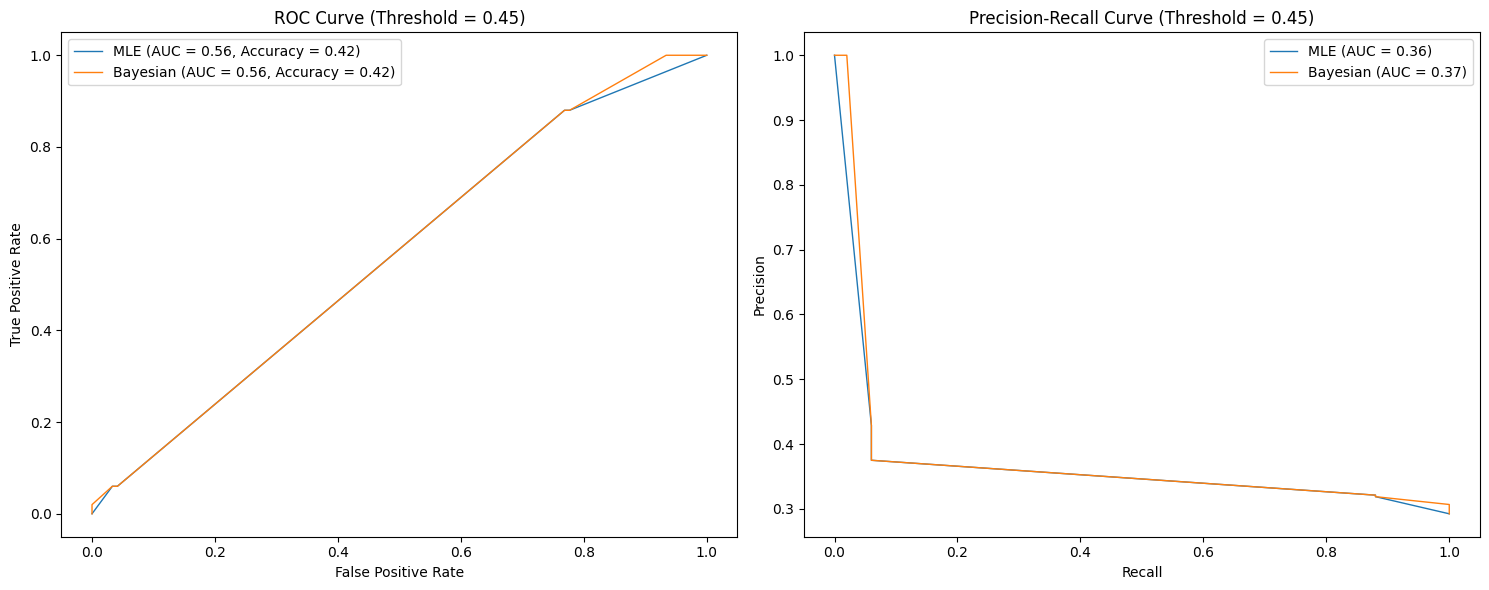

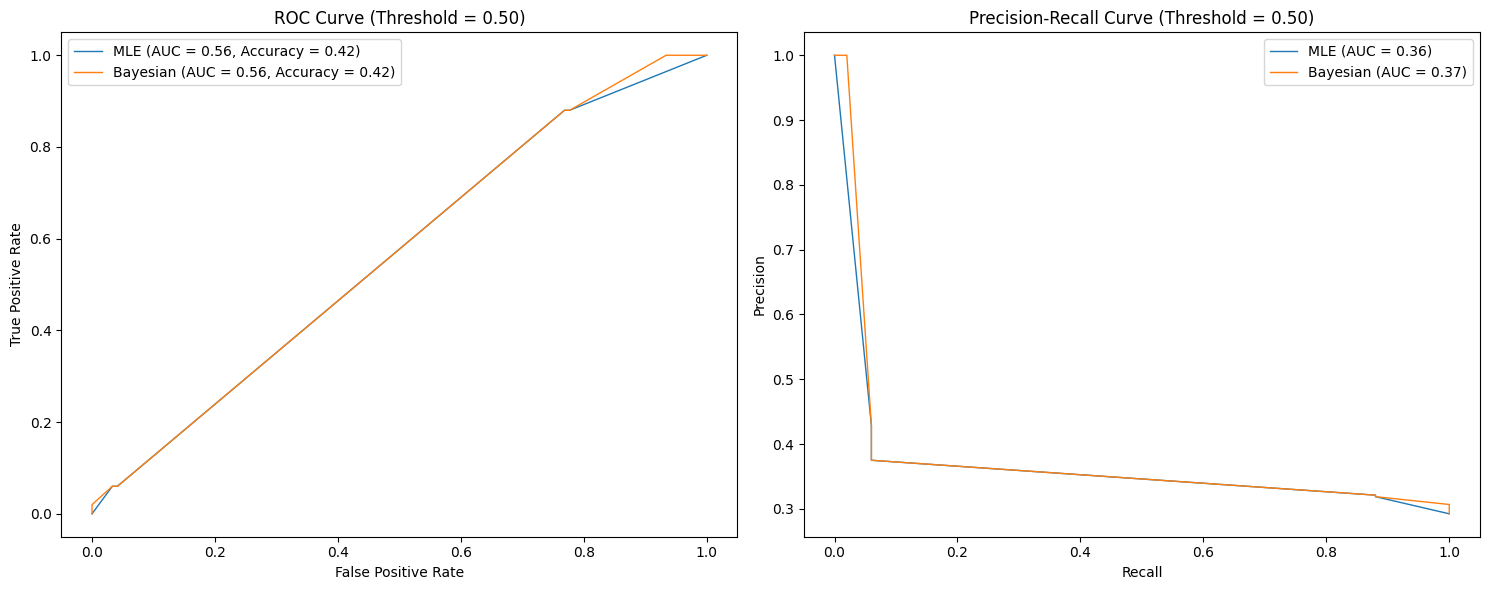

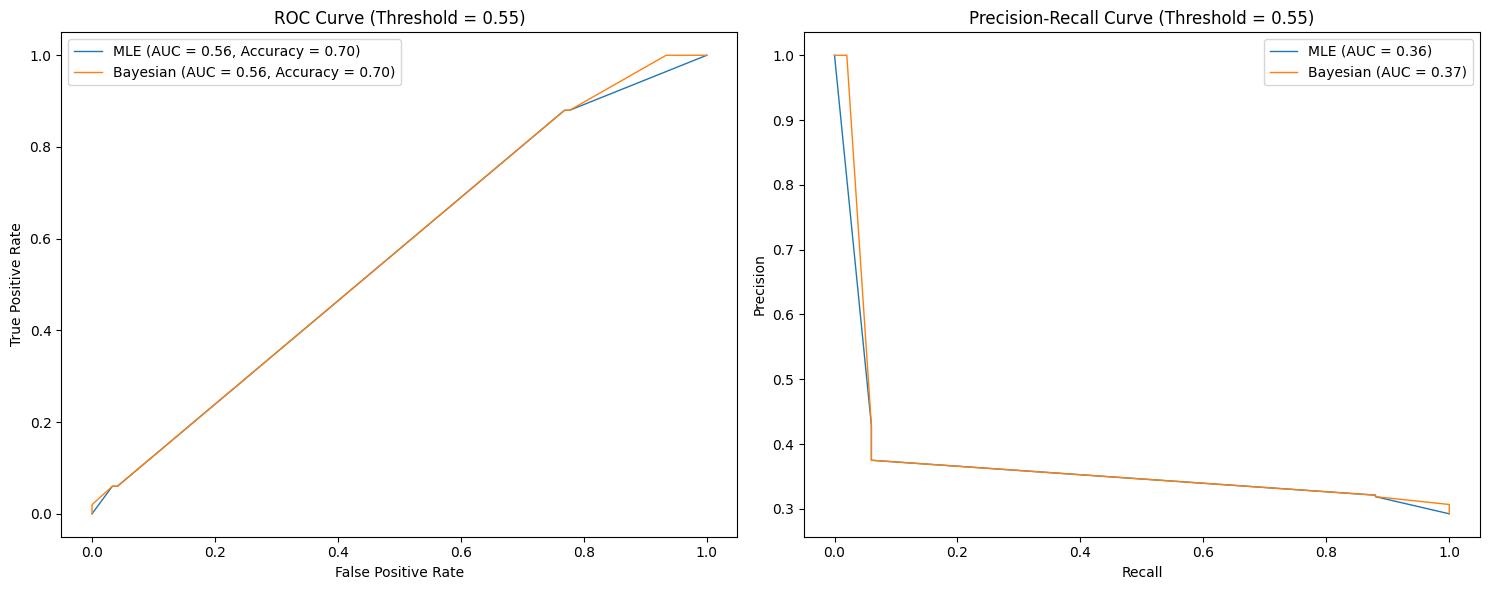

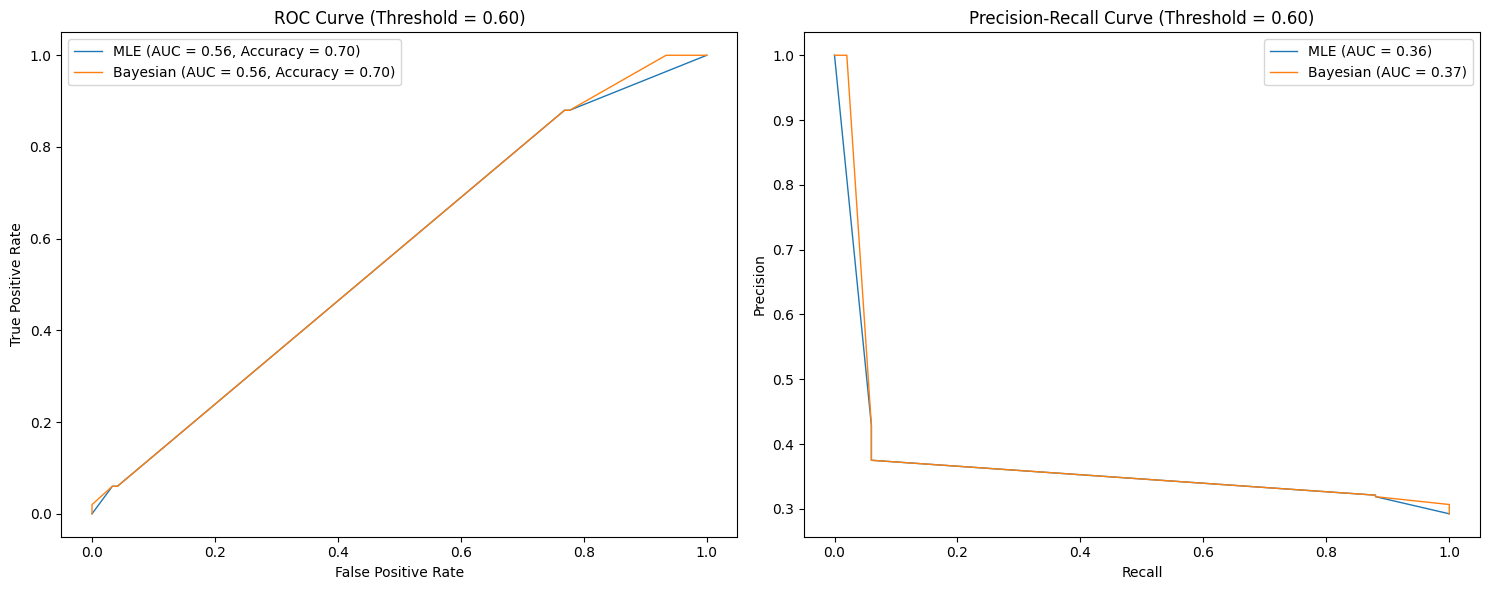

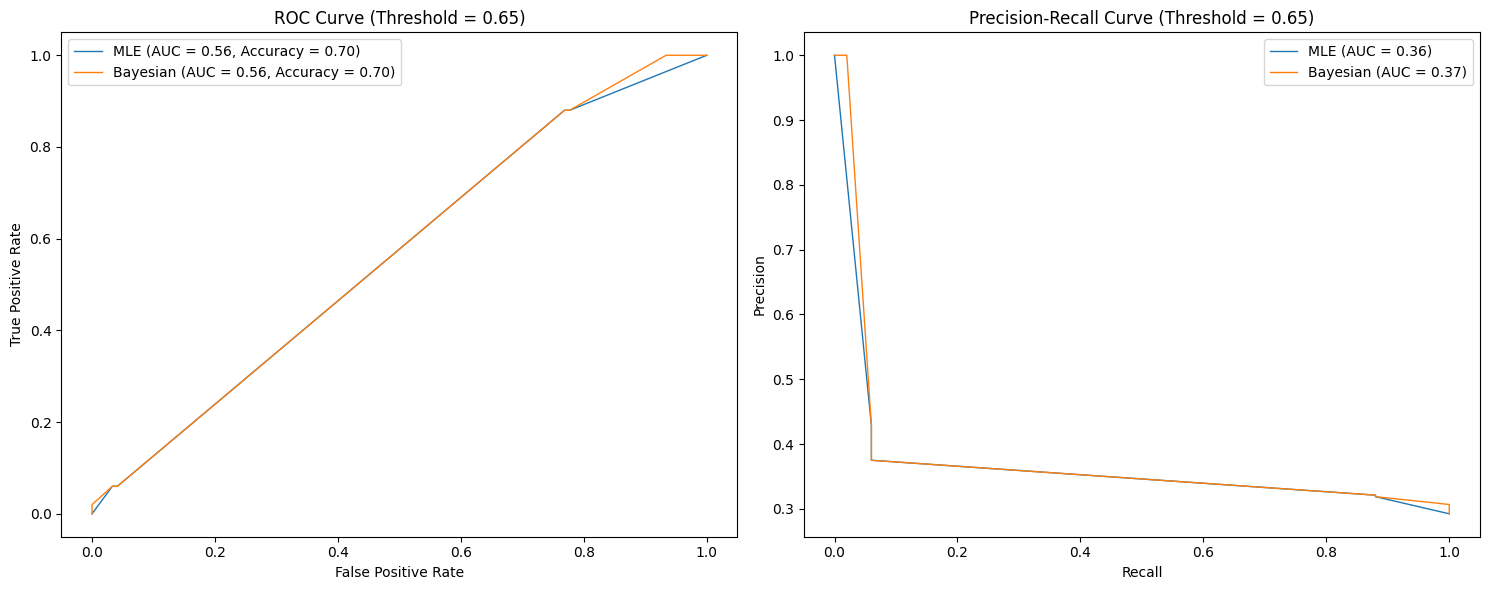

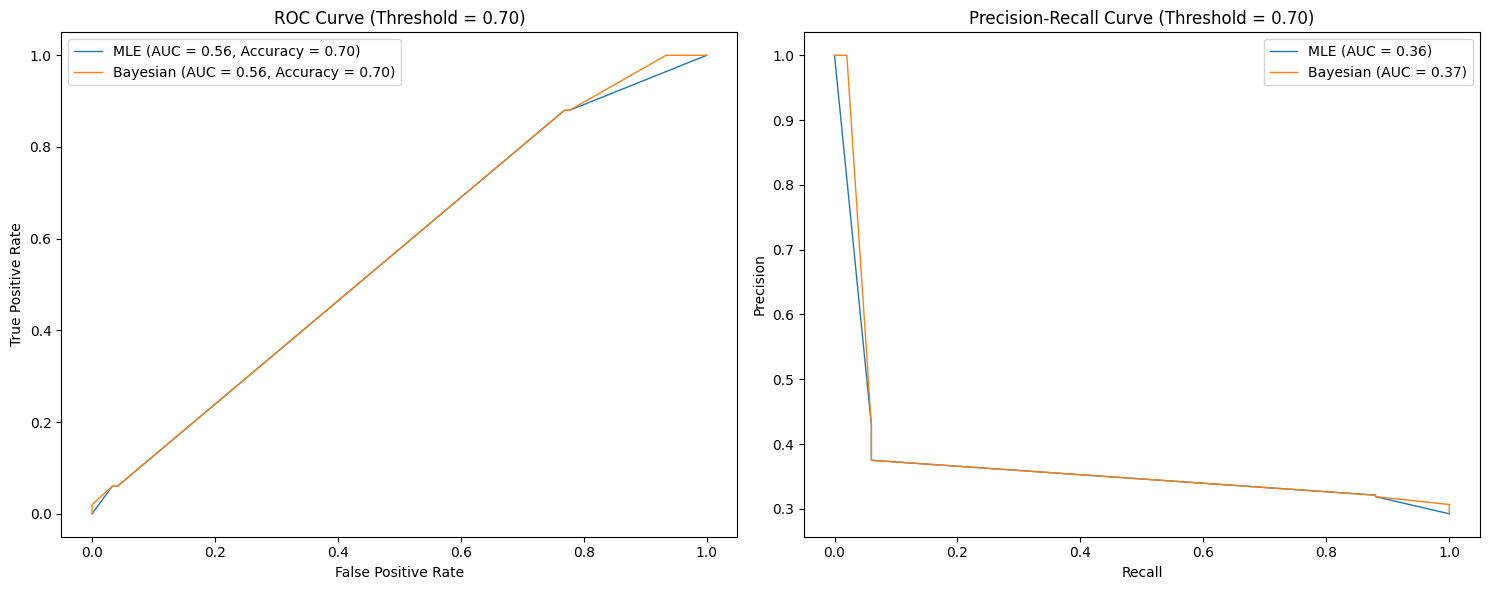

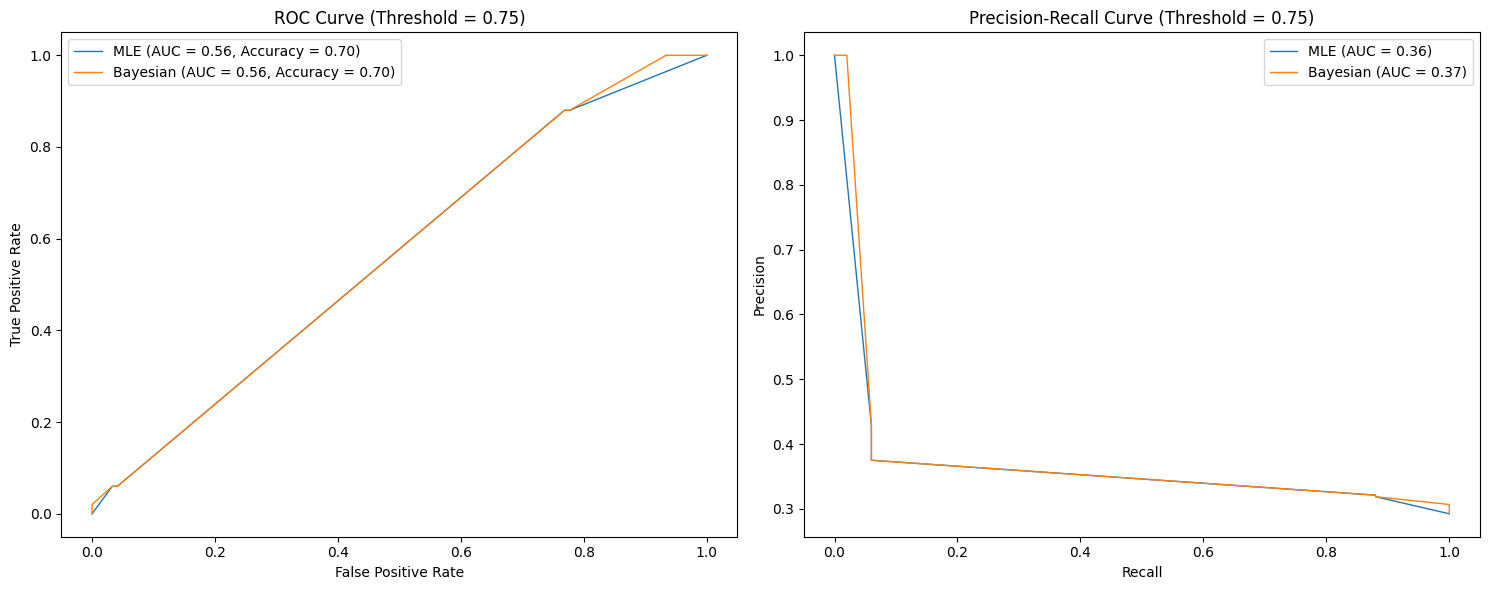

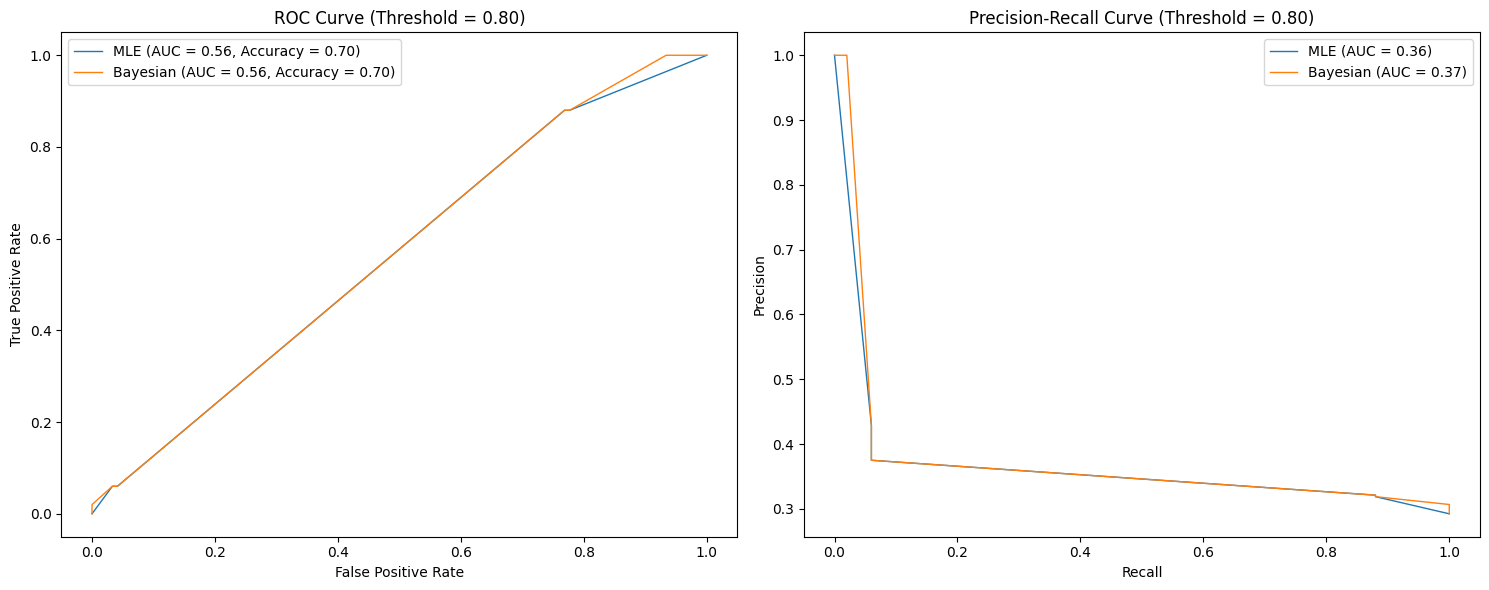

,Threshold,Method,Accuracy,ROC AUC,PR AUC,Precision,Recall,F1,Specificity
0,0.30,MLE,0.415205,0.560331,0.364960,0.318841,0.88,0.468085,0.223140
1,0.30,Bayesian,0.415205,0.564628,0.371536,0.318841,0.88,0.468085,0.223140
2,0.35,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
3,0.35,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405
4,0.40,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
5,0.40,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405
6,0.45,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
7,0.45,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405
8,0.50,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
9,0.50,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405


In [ ]:
target = 'longcovid_four'
features = longcovid1.drop(columns=['longcovid_four'])
X = longcovid1[features.columns]
y = longcovid1['longcovid_four']


X_train, X_test, y_train, y_test = train_test_split(longcovid1, y, test_size=0.35, random_state=42, stratify=y)

thresholds = np.arange(0.3, 0.85, 0.05)
results = {
    'Threshold': [],
    'Method': [],
    'Accuracy': [],
    'ROC AUC': [],
    'PR AUC': [],
    'Precision': [],
    'Recall': [],
    'F1': [],
    'Specificity': []
}

for p in thresholds:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    for method in ["MLE", "Bayesian"]:
        if method == "MLE":
            estimator = MaximumLikelihoodEstimator(bnmodel1, X_train)
        else:
            estimator = BayesianEstimator(bnmodel1, X_train)

        # Estimate CPDs

        columns = longcovid2.columns.tolist()
        for column in columns:
          cpd = estimator.estimate_cpd(column)
          bnmodel1.add_cpds(cpd)


        # Predictions
        infer = VariableElimination(bnmodel1)
        predictions = [infer.query(['longcovid_four'], evidence={k: int(v) for k, v in row.to_dict().items() if k != 'longcovid_four'}).values[1]for _, row in X_test.iterrows()]
        newpred = [1 if pred >= p else 0 for pred in predictions]

        # Metrics
        accuracy = accuracy_score(y_test, newpred)
        precision = precision_score(y_test, newpred)
        recall = recall_score(y_test, newpred)
        f1 = f1_score(y_test, newpred)
        tn, fp, fn, tp = confusion_matrix(y_test, newpred).ravel()
        specificity = tn / (tn + fp)

        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, predictions)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, lw=1, label=f'{method} (AUC = {roc_auc:.2f}, Accuracy = {accuracy:.2f})')

        # PR curve
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, predictions)
        pr_auc = auc(recall_curve, precision_curve)
        ax2.plot(recall_curve, precision_curve, lw=1, label=f'{method} (AUC = {pr_auc:.2f})')

        # Store the results
        results['Threshold'].append(p)
        results['Method'].append(method)
        results['Accuracy'].append(accuracy)
        results['ROC AUC'].append(roc_auc)
        results['PR AUC'].append(pr_auc)
        results['Precision'].append(precision)
        results['Recall'].append(recall)
        results['F1'].append(f1)
        results['Specificity'].append(specificity)

    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve (Threshold = {p:.2f})')
    ax1.legend(loc='best')

    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve (Threshold = {p:.2f})')
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
display(results_df)

In [ ]:
results=pd.DataFrame(results)

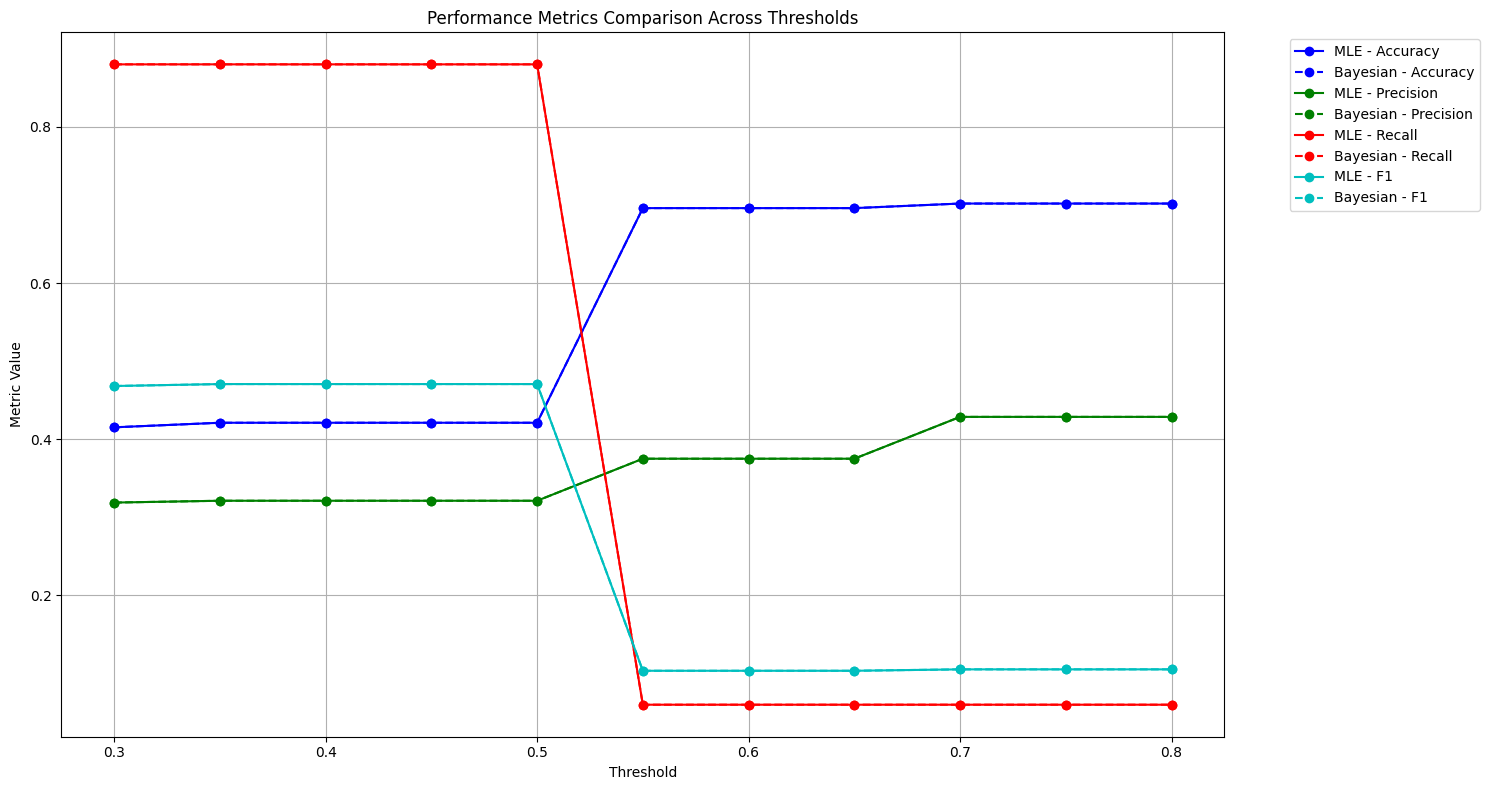

In [ ]:
# Plotting all performance metrics
plt.figure(figsize=(15, 8))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['b', 'g', 'r', 'c']

for i, metric in enumerate(metrics):
    for method in results['Method'].unique():
        subset = results[results['Method'] == method]
        linestyle = '--' if method == 'Bayesian' else '-'
        plt.plot(subset['Threshold'], subset[metric], marker='o', color=colors[i], linestyle=linestyle, label=f'{method} - {metric}')

plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Performance Metrics Comparison Across Thresholds')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Plotting all performance metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['b', 'g', 'r', 'c']

for i, metric in enumerate(metrics):
    # Filter for Bayesian method
    subset = results[results['Method'] == 'Bayesian']
    plt.plot(subset['Threshold'], subset[metric], marker='o', color=colors[i], linestyle='--', label=f'Bayesian - {metric}')

plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Performance Metrics Comparison Across Thresholds')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

,Threshold,Method,Accuracy,ROC AUC,PR AUC,Precision,Recall,F1,Specificity
0,0.30,MLE,0.415205,0.560331,0.364960,0.318841,0.88,0.468085,0.223140
1,0.30,Bayesian,0.415205,0.564628,0.371536,0.318841,0.88,0.468085,0.223140
2,0.35,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
3,0.35,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405
4,0.40,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
5,0.40,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405
6,0.45,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
7,0.45,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405
8,0.50,MLE,0.421053,0.560331,0.364960,0.321168,0.88,0.470588,0.231405
9,0.50,Bayesian,0.421053,0.564628,0.371536,0.321168,0.88,0.470588,0.231405


In [ ]:
results_df.to_csv('lc4results.csv', index=False)
from google.colab import files
files.download('lc4results.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# bnmodel1.to_daft(node_pos={
#     # Background
#     'Age_group': (2, 1),
#     'sex': (2, 2),
#     'education': (2, 3),
#     'smoking': (2, 4),
#     'alcohol': (2, 7),
#     'drugs': (2, 8),
#     'occupation': (2, 5),
#     'occupation_covid': (2, 6),
#     'past_history_covid': (2, 10),
#     'date_diff_four_4_classes': (2, 9),

#     # Underlying Condition
#     'under_cond': (2, 12),
#     'hypertension': (1, 12),
#     'anxiety': (1, 13),
#     'asthma': (1, 14),
#     'cancer': (2, 14),
#     'diabetes': (3, 14),
#     'other_medical': (3, 13),
#     'obesity': (3, 12),
#     'tb': (2, 11),

#     # Vaccines
#     'vaccine_dose': (7, 6),
#     'vaccine_type': (7, 5),
#     'vaccine_effect': (8, 7),

#     # LC Symptoms
#     'lc_fatigue_four': (10.5, 11),
#     'lc_cough_four': (4.5, 11),
#     'lc_headache_four': (5, 10),
#     'lc_breathing_four': (5.5, 11),
#     'lc_taste_four': (6, 10),
#     'lc_smell_four': (6.5, 11),
#     'lc_brainfog_four': (7, 10),
#     'lc_chestpain_four': (7.5, 11),
#     'lc_palpitation_four': (8, 10),
#     'lc_anxiety_four': (8.5, 11),
#     'lc_fever_four': (9, 10),
#     'lc_other_four': (9.5, 11),

#     # Covid Symptoms
#     'covid_severity': (9.5, 1),
#     'covid_care': (8, 1),
#     'Headache': (12, 6.5),
#     'Cough': (11, 6),
#     'Fever': (12, 5.5),
#     'Ageusia': (11, 5),
#     'Anosmia': (12, 4.5),
#     'SoreThroat': (11, 4),
#     'DigestiveIssues': (12, 3.5),
#     'Cold': (11, 3),
#     'OtherSymptoms': (12, 2.5),
#     'Bodyache': (11, 2),
#     'BreathingDifficulty': (12, 1.5),
#     'NasalIssues': (11, 1),
#     'Fatigue': (12, 7.5),
#     'ChestPain': (11, 7),

#     # LONG COVID
#     'longcovid_four': (5, 2),
#     'longcovid_six': (6, 7),
#     'lc_activitylimit_four': (5, 4.5),
#     'lc_consultation_four': (6, 4.5)}).render()

In [ ]:
target = 'longcovid_six'
# Define features as all columns except the target column
features = longcovid1.drop(columns=[target])


# Splitting the data
X = longcovid1.drop(columns=[target])
y = longcovid1[target]

In [ ]:
# Get the variable names from the Bayesian network model
variable_names_in_model = set(bnmodel1.nodes)

# Get the column names from your training data
column_names_in_data = set(longcovid1.columns)

# Identify missing columns (in the model but not in the data)
missing_columns = variable_names_in_model - column_names_in_data

# Identify excessive columns (in the data but not in the model)
excessive_columns = column_names_in_data - variable_names_in_model

# Print the results
print("Missing Columns (in the model but not in the data):", missing_columns)
print("Excessive Columns (in the data but not in the model):", excessive_columns)

Missing Columns (in the model but not in the data): set()
Excessive Columns (in the data but not in the model): {'education', 'ChestPain', 'smoking', 'drugs', 'Headache', 'date_diff_four_4_classes', 'lc_brainfog_four', 'lc_fever_four', 'tb'}


In [ ]:
# KFold configuration
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
thresholds = np.arange(0.3, 0.85, 0.05)